# Standard library imports


In [6]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Install extra packages


In [7]:
'''# — Install packages & Download dataset only required for google colab or new environments. If running locally with all packages installed, skip this cell.
import subprocess, sys, os

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# ── Install required packages ─────────────────────────────────────────────────
install('shap')
install('lime')
install('PyWavelets')
install('wfdb')
install('gdown')

import shap
import lime
import lime.lime_tabular
import pywt
import wfdb
import gdown

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── Download dataset from Google Drive ─────────────────────────────────────────
DRIVE_URL  = 'https://drive.google.com/drive/folders/1SElbnxiI3vECR9Mj3Ih_YhNL8cY6KyN5'
DATA_DIR   = 'dataset'

if not os.path.exists(DATA_DIR):
    print(f'Downloading dataset from Google Drive into ./{DATA_DIR}/ ...')
    gdown.download_folder(DRIVE_URL, output=DATA_DIR, quiet=False)
    print(f'\n✓ Dataset downloaded to ./{DATA_DIR}/')
else:
    print(f'✓ Dataset already exists at ./{DATA_DIR}/ — skipping download')

# ── List downloaded files ──────────────────────────────────────────────────────
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in sorted(files):
        size_mb = os.path.getsize(os.path.join(root, f)) / (1024*1024)
        print(f'{indent}  {f} ({size_mb:.1f} MB)')

print('\n✓ All packages ready')
'''

"# — Install packages & Download dataset only required for google colab or new environments. If running locally with all packages installed, skip this cell.\nimport subprocess, sys, os\n\ndef install(pkg):\n    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])\n\n# ── Install required packages ─────────────────────────────────────────────────\ninstall('shap')\ninstall('lime')\ninstall('PyWavelets')\ninstall('wfdb')\ninstall('gdown')\n\nimport shap\nimport lime\nimport lime.lime_tabular\nimport pywt\nimport wfdb\nimport gdown\n\nfrom sklearn.svm import SVC\nfrom sklearn.tree import DecisionTreeClassifier, plot_tree\n\n# ── Download dataset from Google Drive ─────────────────────────────────────────\nDRIVE_URL  = 'https://drive.google.com/drive/folders/1SElbnxiI3vECR9Mj3Ih_YhNL8cY6KyN5'\nDATA_DIR   = 'dataset'\n\nif not os.path.exists(DATA_DIR):\n    print(f'Downloading dataset from Google Drive into ./{DATA_DIR}/ ...')\n    gdown.download_folder(DRIVE_URL, outpu

# Core data libraries


In [8]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import FastICA
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# Select compute device


In [9]:
# Cell 7
# Select compute device
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')

PyTorch : 2.1.1+cu118
Device  : cuda


In [10]:
import os
import pandas as pd

WORKER_PATH = r"F:\TAN paper\dataset\stress-recognition-in-automobile-drivers-1.0.0\worker_data"

all_data = []

for file in os.listdir(WORKER_PATH):
    if file.endswith(".csv"):
        worker_id = int(file.replace("worker", "").replace(".csv", ""))
        df = pd.read_csv(os.path.join(WORKER_PATH, file))
        df["worker"] = worker_id
        all_data.append(df)

data = pd.concat(all_data, ignore_index=True)

print("Data loaded successfully!")

Data loaded successfully!


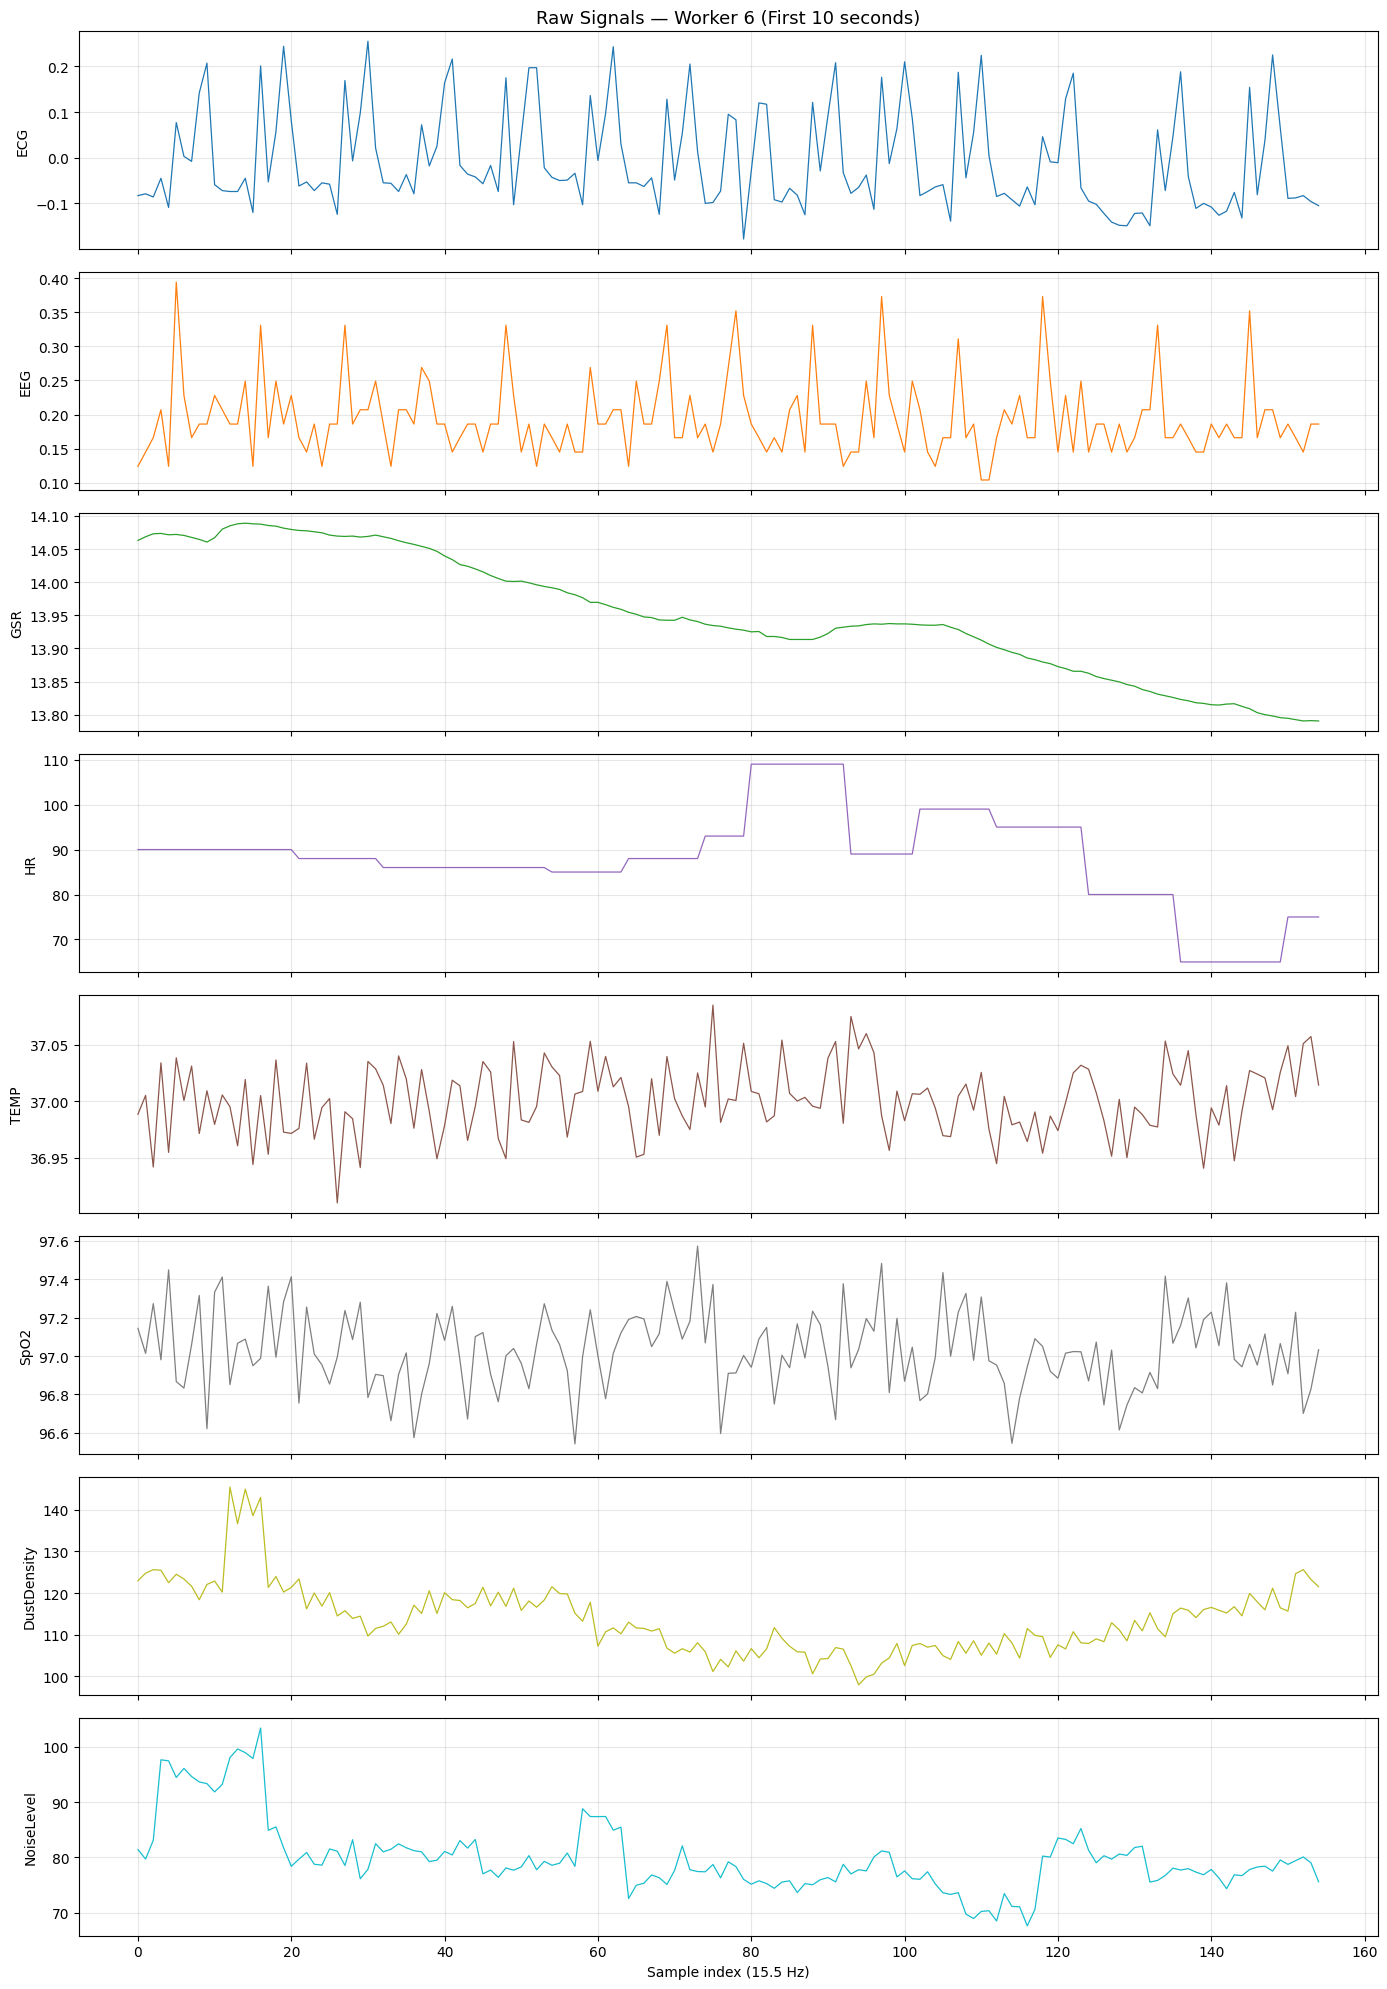

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# CONFIG
# ==============================
subject_id = 6
FILE_PATH = f"{WORKER_PATH}/worker{subject_id}.csv"
FS = 15.5
DURATION = 10

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv(FILE_PATH)

num_samples = int(FS * DURATION)
sample_worker = df.iloc[:num_samples].copy()

# ==============================
# CREATE AVERAGED GSR
# ==============================
if "hand GSR" in sample_worker.columns and "foot GSR" in sample_worker.columns:
    sample_worker["GSR"] = (
        sample_worker["hand GSR"] + sample_worker["foot GSR"]
    ) / 2

# ==============================
# SELECT SIGNAL COLUMNS
# ==============================
exclude_cols = ["time", "marker", "hand GSR", "foot GSR"]
signal_cols = [col for col in sample_worker.columns if col not in exclude_cols]

# ==============================
# DEFINE ORDER
# ==============================
base_order = ["ECG", "EEG", "GSR"]

exclude_cols = ["time", "marker", "hand GSR", "foot GSR"]

# Remaining columns (excluding already placed ones)
remaining_cols = [
    col for col in sample_worker.columns
    if col not in exclude_cols + base_order
]

# Final ordered list
signal_cols = base_order + remaining_cols

# Keep only existing columns
signal_cols = [col for col in signal_cols if col in sample_worker.columns]

# ==============================
# COLOR SETUP
# ==============================
colors = plt.cm.tab10(np.linspace(0, 1, len(signal_cols)))

# ==============================
# PLOTTING
# ==============================
num_signals = len(signal_cols)

fig, axes = plt.subplots(num_signals, 1, figsize=(14, 2.5 * num_signals), sharex=True)

if num_signals == 1:
    axes = [axes]

for ax, col, color in zip(axes, signal_cols, colors):
    ax.plot(sample_worker[col].values, linewidth=0.9, color=color)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_title(f"Raw Signals — Worker {subject_id} (First 10 seconds)", fontsize=13)
axes[-1].set_xlabel(f"Sample index ({FS} Hz)", fontsize=10)

plt.tight_layout()
plt.show()

Workers with HIGH Dust Exposure (>150 µg/m³): [3, 4, 16, 21, 32, 39, 47]
Workers with HIGH Noise Exposure (>80 dB): [6, 7, 8, 10, 12, 14, 15, 16, 18, 21, 22, 26, 30, 32, 33, 39, 41, 43, 44, 46, 47, 50]

Detected High Fatigue Workers:
[3, 4, 6, 7, 8, 10, 12, 14, 15, 16, 18, 21, 22, 26, 30, 32, 33, 39, 41, 43, 44, 46, 47, 50]


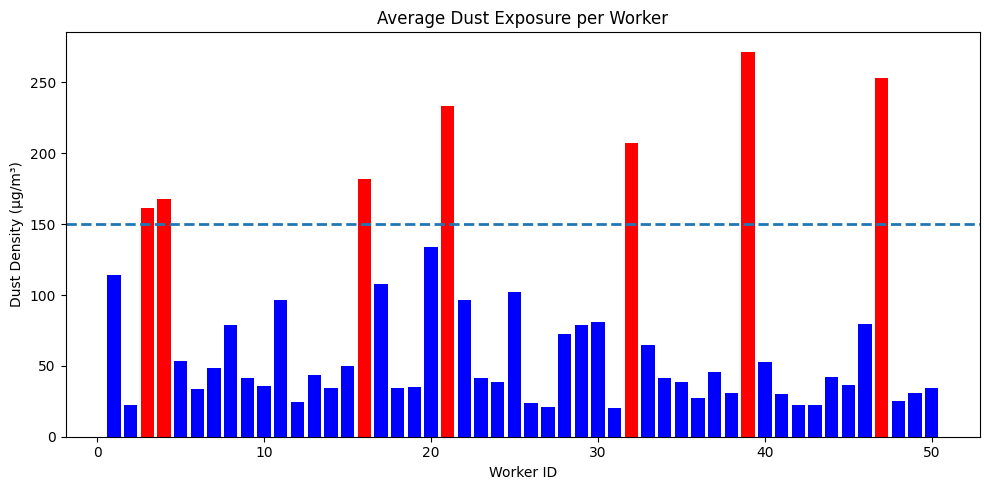

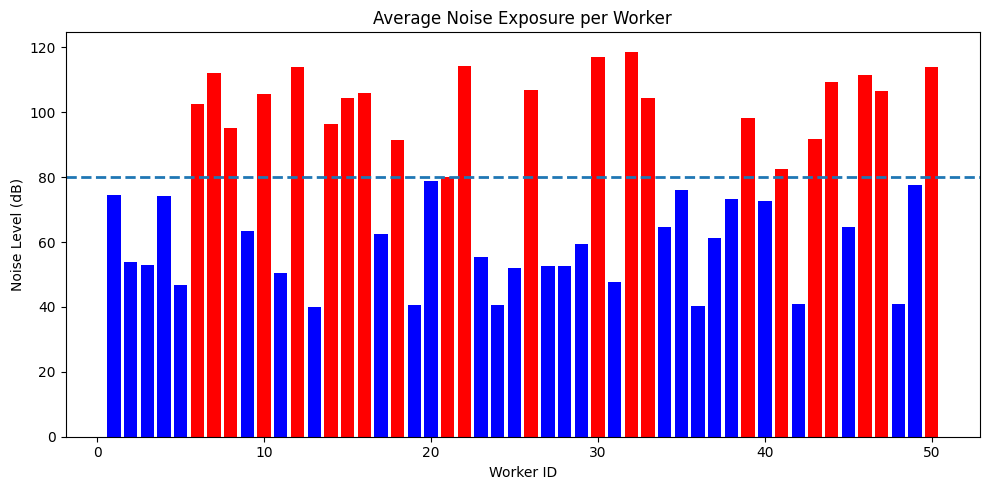

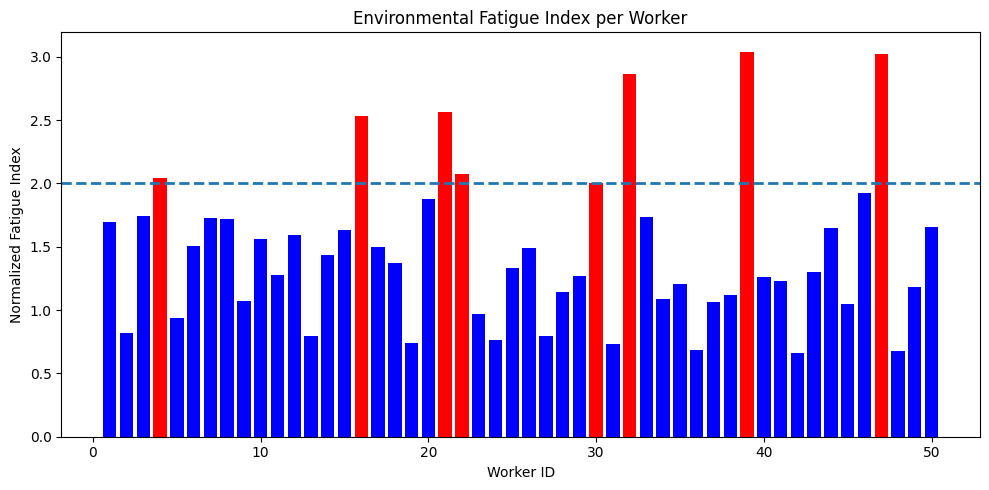

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt

NOISE_THRESHOLD = 80  # dB
DUST_THRESHOLD = 150  # µg/m³   
# ==============================
# SUMMARY (PER WORKER)
# ==============================
summary = data.groupby("worker")[["DustDensity", "NoiseLevel"]].mean().reset_index()

# ==============================
# CLASSIFICATION (DATA-DRIVEN)
# ==============================
def classify_worker(row):
    if (row["DustDensity"] > DUST_THRESHOLD) or (row["NoiseLevel"] > NOISE_THRESHOLD):
        return "High Fatigue"
    else:
        return "Normal"

summary["group"] = summary.apply(classify_worker, axis=1)

# Map group back to full dataset
worker_group_map = dict(zip(summary["worker"], summary["group"]))
data["group"] = data["worker"].map(worker_group_map)

# ==============================
# PRINT RESULTS
# ==============================
high_dust_workers = summary[summary["DustDensity"] > DUST_THRESHOLD]["worker"].tolist()
high_noise_workers = summary[summary["NoiseLevel"] > NOISE_THRESHOLD]["worker"].tolist()

print("Workers with HIGH Dust Exposure (>150 µg/m³):", high_dust_workers)
print("Workers with HIGH Noise Exposure (>80 dB):", high_noise_workers)

print("\nDetected High Fatigue Workers:")
print(summary[summary["group"] == "High Fatigue"]["worker"].tolist())

# ==============================
# SORT FOR CLEAN VISUALIZATION
# ==============================
summary = summary.sort_values("worker")

# ==============================
# PLOT 1 — DUST DENSITY
# ==============================
fig, ax = plt.subplots(figsize=(10,5))

colors = ["red" if val > DUST_THRESHOLD else "blue" for val in summary["DustDensity"]]

ax.bar(summary["worker"], summary["DustDensity"], color=colors)

# Threshold line
ax.axhline(DUST_THRESHOLD, linestyle='--', linewidth=2)

ax.set_title("Average Dust Exposure per Worker")
ax.set_xlabel("Worker ID")
ax.set_ylabel("Dust Density (µg/m³)")

plt.tight_layout()
plt.show()

# ==============================
# PLOT 2 — NOISE LEVEL
# ==============================
fig, ax = plt.subplots(figsize=(10,5))

colors = ["red" if val > NOISE_THRESHOLD else "blue" for val in summary["NoiseLevel"]]

ax.bar(summary["worker"], summary["NoiseLevel"], color=colors)

# Threshold line
ax.axhline(NOISE_THRESHOLD, linestyle='--', linewidth=2)

ax.set_title("Average Noise Exposure per Worker")
ax.set_xlabel("Worker ID")
ax.set_ylabel("Noise Level (dB)")

plt.tight_layout()
plt.show()

# ==============================
# OPTIONAL: ENVIRONMENTAL Fatigue INDEX (BEST FOR PAPER)
# ==============================
summary["EnvFatigueIndex"] = (
    summary["DustDensity"] / DUST_THRESHOLD +
    summary["NoiseLevel"] / NOISE_THRESHOLD
)

fig, ax = plt.subplots(figsize=(10,5))

colors = ["red" if val > 2 else "blue" for val in summary["EnvFatigueIndex"]]

ax.bar(summary["worker"], summary["EnvFatigueIndex"], color=colors)

ax.axhline(2, linestyle='--', linewidth=2)

ax.set_title("Environmental Fatigue Index per Worker")
ax.set_xlabel("Worker ID")
ax.set_ylabel("Normalized Fatigue Index")

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_ind

# ==============================
# THRESHOLDS
# ==============================
DUST_THRESHOLD = 150
NOISE_THRESHOLD = 80

# ==============================
# SUMMARY PER WORKER (IMPORTANT FIX)
# ==============================
summary = data.groupby("worker")[["DustDensity", "NoiseLevel"]].mean().reset_index()

# ==============================
# ENVIRONMENTAL Fatigue INDEX (WORKER LEVEL)
# ==============================
summary["EnvFatigueIndex"] = (
    summary["DustDensity"] / DUST_THRESHOLD +
    summary["NoiseLevel"] / NOISE_THRESHOLD
)

# ==============================
# CLASSIFICATION (WORKER LEVEL)
# ==============================
def classify_worker(row):
    if (row["DustDensity"] > DUST_THRESHOLD) or (row["NoiseLevel"] > NOISE_THRESHOLD):
        return "High Fatigue"
    return "Normal"

summary["group"] = summary.apply(classify_worker, axis=1)

# ==============================
# PROPER OUTLIER REMOVAL (NOT CLIPPING)
# ==============================
def remove_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return series[(series >= lower) & (series <= upper)]

# Apply filtering
summary_clean = summary.copy()

summary_clean["NoiseLevel"] = remove_outliers(summary["NoiseLevel"])
summary_clean["EnvFatigueIndex"] = remove_outliers(summary["EnvFatigueIndex"])

# Drop NaNs introduced by filtering
summary_clean = summary_clean.dropna()

# ==============================
# STATISTICAL TEST
# ==============================
normal_noise = summary_clean[summary_clean["group"] == "Normal"]["NoiseLevel"]
Fatigue_noise = summary_clean[summary_clean["group"] == "High Fatigue"]["NoiseLevel"]

normal_env = summary_clean[summary_clean["group"] == "Normal"]["EnvFatigueIndex"]
Fatigue_env = summary_clean[summary_clean["group"] == "High Fatigue"]["EnvFatigueIndex"]

t_noise, p_noise = ttest_ind(Fatigue_noise, normal_noise)
t_env, p_env = ttest_ind(Fatigue_env, normal_env)

print("\n===== STATISTICAL Test =====")
def format_p(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

print(f"Noise Level: t = {t_noise:.3f}, {format_p(p_noise)}")
print(f"Env Fatigue Index: t = {t_env:.3f}, {format_p(p_env)}")

def cohens_d(a, b):
    mean_diff = np.mean(a) - np.mean(b)
    pooled_std = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
    return mean_diff / pooled_std

d_noise = cohens_d(Fatigue_noise, normal_noise)
d_env = cohens_d(Fatigue_env, normal_env)

print(f"Cohen's d (Noise): {d_noise:.2f}")
print(f"Cohen's d (Env Index): {d_env:.2f}")

from scipy.stats import mannwhitneyu

u_stat, p_u = mannwhitneyu(Fatigue_noise, normal_noise)
print(f"Mann-Whitney p-value: {format_p(p_u)}")


===== STATISTICAL Test =====
Noise Level: t = 9.995, p < 0.001
Env Fatigue Index: t = 6.887, p < 0.001
Cohen's d (Noise): 2.90
Cohen's d (Env Index): 2.01
Mann-Whitney p-value: p < 0.001


<Figure size 800x500 with 0 Axes>

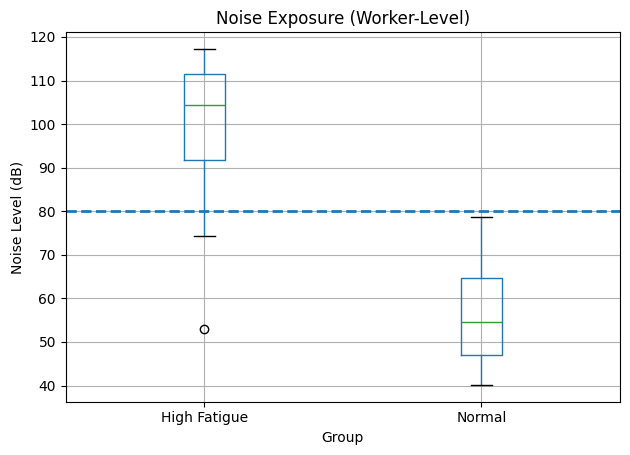

<Figure size 800x500 with 0 Axes>

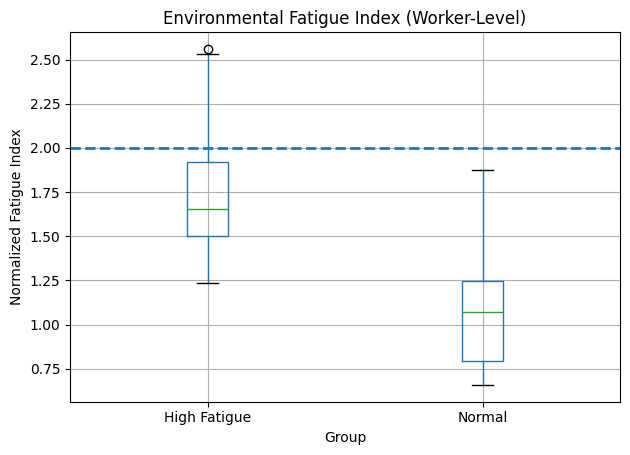

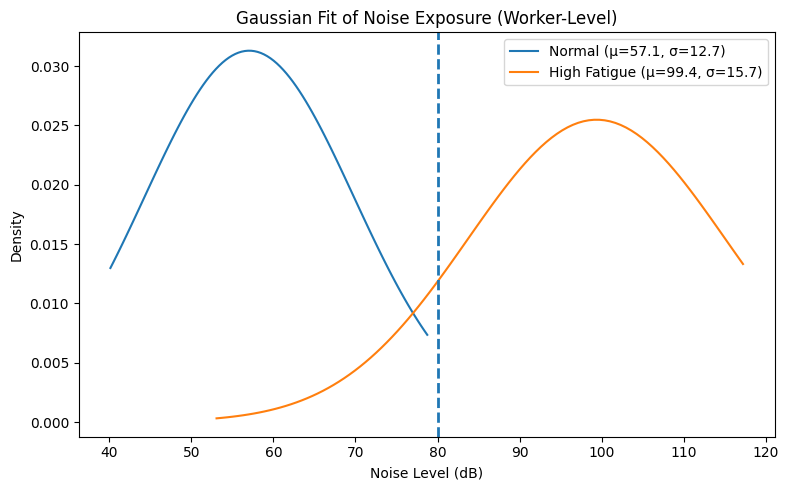

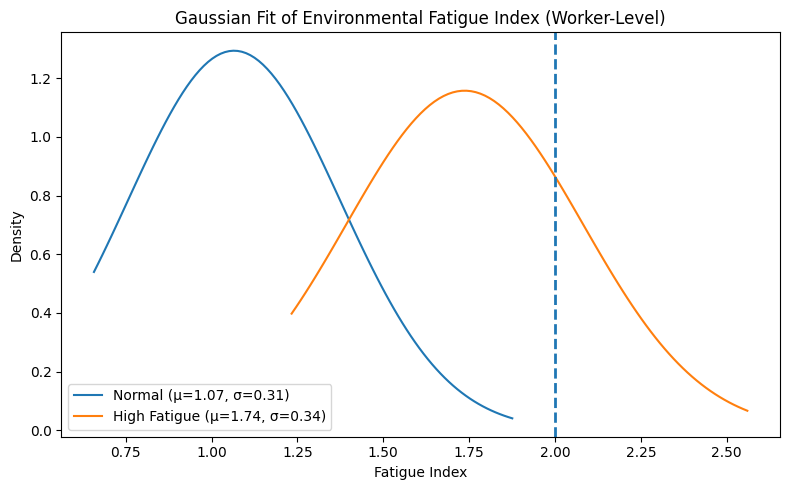

In [14]:
# ==============================
# BOXPLOT (NOISE)
# ==============================
plt.figure(figsize=(8,5))

summary_clean.boxplot(column="NoiseLevel", by="group")

plt.axhline(NOISE_THRESHOLD, linestyle='--', linewidth=2)

plt.title("Noise Exposure (Worker-Level)")
plt.suptitle("")
plt.xlabel("Group")
plt.ylabel("Noise Level (dB)")

plt.tight_layout()
plt.show()

# ==============================
# BOXPLOT (ENV INDEX)
# ==============================
plt.figure(figsize=(8,5))

summary_clean.boxplot(column="EnvFatigueIndex", by="group")

plt.axhline(2, linestyle='--', linewidth=2)

plt.title("Environmental Fatigue Index (Worker-Level)")
plt.suptitle("")
plt.xlabel("Group")
plt.ylabel("Normalized Fatigue Index")

plt.tight_layout()
plt.show()

# ==============================
# GAUSSIAN (NOISE)
# ==============================
plt.figure(figsize=(8,5))

for group in ["Normal", "High Fatigue"]:
    subset = summary_clean[summary_clean["group"] == group]["NoiseLevel"]

    mu, std = norm.fit(subset)
    x = np.linspace(subset.min(), subset.max(), 100)

    plt.plot(x, norm.pdf(x, mu, std), label=f"{group} (μ={mu:.1f}, σ={std:.1f})")

plt.axvline(NOISE_THRESHOLD, linestyle='--', linewidth=2)

plt.title("Gaussian Fit of Noise Exposure (Worker-Level)")
plt.xlabel("Noise Level (dB)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

# ==============================
# GAUSSIAN (ENV INDEX)
# ==============================
plt.figure(figsize=(8,5))

for group in ["Normal", "High Fatigue"]:
    subset = summary_clean[summary_clean["group"] == group]["EnvFatigueIndex"]

    mu, std = norm.fit(subset)
    x = np.linspace(subset.min(), subset.max(), 100)

    plt.plot(x, norm.pdf(x, mu, std), label=f"{group} (μ={mu:.2f}, σ={std:.2f})")

plt.axvline(2, linestyle='--', linewidth=2)

plt.title("Gaussian Fit of Environmental Fatigue Index (Worker-Level)")
plt.xlabel("Fatigue Index")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

# Load compiled Workers Dataset 

In [15]:
# Load pre-converted dataset (from convert_to_dataset.py)
import pandas as pd
import numpy as np

CSV_PATH = r"F:\TAN paper\workers_dataset.csv\workers_dataset.csv"
raw = pd.read_csv(CSV_PATH)

print(f'Loaded {len(raw):,} rows, {raw["worker_id"].nunique()} workers')
print(f'Columns: {raw.columns.tolist()}')

# ── Column mapping to match notebook schema ─────────────────────────────────
# 1. worker_id (str like '01','17a') → worker (int where possible)
#    Workers with letter suffixes (17a, 17b) get mapped to unique ints
worker_map = {}
next_id = 100  # for non-numeric IDs
for wid in raw['worker_id'].unique():
    try:
        worker_map[wid] = int(wid)
    except ValueError:
        worker_map[wid] = next_id
        next_id += 1

data = pd.DataFrame()
data['worker'] = raw['worker_id'].map(worker_map)

# 2. ECG stays as ECG
data['ECG'] = raw['ECG']

# 3. EMG → EEG (surrogate, matching original notebook convention)
data['EEG'] = raw['EMG'].fillna(0.0)

# 4. GSR = average of foot_GSR and hand_GSR
data['GSR'] = raw[['foot_GSR', 'hand_GSR']].mean(axis=1)

# 5. marker channel (for labelling)
data['marker'] = raw['marker']

print(f'\nMapped dataset: {len(data):,} rows, {data["worker"].nunique()} workers')
print(f'Columns: {data.columns.tolist()}')
print(f'\nWorker IDs: {sorted(data["worker"].unique())}')
print(f'\nFirst 5 rows:')
print(data.head())


Loaded 3,568,924 rows, 49 workers
Columns: ['worker_id', 'sample_idx', 'ECG', 'EMG', 'foot_GSR', 'hand_GSR', 'HR', 'marker', 'Body_TEMP']

Mapped dataset: 3,568,924 rows, 47 workers
Columns: ['worker', 'ECG', 'EEG', 'GSR', 'marker']

Worker IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 100, 101]

First 5 rows:
   worker    ECG     EEG     GSR  marker
0       1 -0.030 -0.0072  6.8250     NaN
1       1 -0.026 -0.0033  6.8240     NaN
2       1 -0.016  0.0019  6.8205     NaN
3       1 -0.020 -0.0030  6.8175     NaN
4       1 -0.395 -0.0020  6.8115     NaN


# Basic inspection of raw data

In [16]:
print('=== Data Shape ===')
print(f'Rows: {len(data):,}  |  Columns: {len(data.columns)}')
print('\n=== First 5 rows ===')
print(data.head(17))
print('\n=== Data Types ===')
print(data.dtypes)

=== Data Shape ===
Rows: 3,568,924  |  Columns: 5

=== First 5 rows ===
    worker    ECG     EEG     GSR  marker
0        1 -0.030 -0.0072  6.8250     NaN
1        1 -0.026 -0.0033  6.8240     NaN
2        1 -0.016  0.0019  6.8205     NaN
3        1 -0.020 -0.0030  6.8175     NaN
4        1 -0.395 -0.0020  6.8115     NaN
5        1  0.007 -0.0109  6.8050     NaN
6        1  0.059 -0.0091  6.8000     NaN
7        1  0.047 -0.0022  6.7940     NaN
8        1 -0.025 -0.0056  6.7640     NaN
9        1  0.000 -0.0025  6.7560     NaN
10       1  0.008 -0.0023  6.7465     NaN
11       1  0.019 -0.0018  6.7365     NaN
12       1 -0.371  0.0001  6.7270     NaN
13       1  0.054 -0.0133  6.7180     NaN
14       1  0.058 -0.0035  6.7085     NaN
15       1  0.031  0.0003  6.6975     NaN
16       1  0.011 -0.0168  6.6890     NaN

=== Data Types ===
worker      int64
ECG       float64
EEG       float64
GSR       float64
marker    float64
dtype: object


# Per-Worker signal statistics

In [17]:
# Per-Worker signal statistics
print('=== Per-Worker Signal Statistics ===')
summary = []
for worker in sorted(data['worker'].unique()):
    d = data[data['worker'] == worker]
    summary.append({
        'worker'  : worker,
        'rows'    : len(d),
        'ECG_nan' : d['ECG'].isna().sum(),
        'EEG_nan' : d['EEG'].isna().sum(),
        'GSR_nan' : d['GSR'].isna().sum(),
        'ECG_mean': round(d['ECG'].mean(), 3),
        'GSR_mean': round(d['GSR'].mean(), 3)
    })
print(pd.DataFrame(summary).to_string(index=False))

=== Per-Worker Signal Statistics ===
 worker   rows  ECG_nan  EEG_nan  GSR_nan  ECG_mean  GSR_mean
      1  61499        0        0        0     0.004    10.798
      2  78056        0        0        0    -0.008     1.859
      3 172447        0        0        0     0.003     2.417
      4  76266        0        0        0    -0.000    13.834
      5  78367        0        0        0    -0.593     5.325
      6  75123        0        0        0    -0.003    13.503
      7  82442        0        0        0    -0.003     9.073
      8  75509        0        0        0    -0.008     5.055
      9  65912        0        0        0    -0.006     4.925
     10  75592        0        0        0    -0.004     7.403
     11  75533        0        0        0     0.001     5.714
     12  77257        0        0        0    -0.004     8.510
     13  74836        0        0        0    -0.005    11.082
     14  74836        0        0        0    -0.005    14.212
     15  72209        0        0 

# Overall signal distributions and NaN counts

In [18]:
# Overall signal distributions and NaN counts
print('=== Overall Signal Distributions ===')
print(data[['ECG', 'EEG', 'GSR']].describe().round(4))
print('\n=== Total NaNs per column ===')
print(data[['ECG', 'EEG', 'GSR']].isna().sum())
print('\n=== Rows per worker ===')
print(data.groupby('worker').size().to_string())

=== Overall Signal Distributions ===
                ECG           EEG           GSR
count  3.568924e+06  3.568924e+06  3.568924e+06
mean  -4.120000e-02  4.986000e-01  7.418900e+00
std    6.592000e-01  1.107200e+00  4.844400e+00
min   -1.000000e+01 -3.276000e+01 -1.230000e+01
25%   -8.900000e-02  0.000000e+00  2.951500e+00
50%   -3.500000e-02  2.098000e-01  6.612500e+00
75%    4.900000e-02  5.180000e-01  1.120650e+01
max    9.952000e+00  3.261000e+01  2.865650e+01

=== Total NaNs per column ===
ECG    0
EEG    0
GSR    0
dtype: int64

=== Rows per worker ===
worker
1       61499
2       78056
3      172447
4       76266
5       78367
6       75123
7       82442
8       75509
9       65912
10      75592
11      75533
12      77257
13      74836
14      74836
15      72209
16      60418
18      61499
19      78056
20     172447
21      76266
22      78367
23      75123
24      82442
25      75509
26      65912
27      75592
28      75533
29      77257
30      74836
31      74836
32      

In [19]:
import matplotlib.pyplot as plt
FS = 15.5 # Hz
first_worker = sorted(data['worker'].unique())[0]
n_plot = int(10 * FS)
sample_worker = data[data['worker'] == first_worker].iloc[:n_plot]


In [20]:
import pandas as pd
import numpy as np

############### KEYWORDS ###################
'''
NSP = Non-Fatigued Period
MSP = Medium-Fatigued Period
HSP = High-Fatigued Period
'''
############################################

FS = 15.5  # Hz — confirmed from record.fs

MARKER_CSV = r"F:\TAN paper\workers_dataset.csv\marker_info.csv"
marker_data = pd.read_csv(MARKER_CSV)


def calculate_starting_times(data):
    result = data.copy()
    result['NSP1'] = 0  # always starts at 0
    period_cols = data.iloc[:, 1:8].columns  # Rest1 through NSP2
    for i, col in enumerate(period_cols):
        if i < len(period_cols) - 1:
            next_col = period_cols[i + 1]
            result[next_col] = result[col] + data[col]
    return result

processed_markers = calculate_starting_times(marker_data)
print('Starting times (minutes):')
print(processed_markers[['Worker','NSP1','HSP1','MSP1',
                          'HSP2','MSP2','HSP3','NSP2']].to_string())

# ── Step 2: Build label array for each covered worker ─────────────────────
period_cols = ['NSP1', 'HSP1', 'MSP1', 'HSP2', 'MSP2', 'HSP3', 'NSP2']

# Map each period to its Fatigue label
period_labels = {
    'NSP1'    : 0,   # Relaxed
    'HSP1'    : 2,   # High-Fatigued
    'MSP1'    : 1,   # Medium
    'HSP2'    : 2,   # Fatigue
    'MSP2'    : 1,   # Medium
    'HSP3'    : 2,   # Fatigue
    'NSP2'    : 0,   # Relaxed
}

covered_workers = []   # worker IDs we can properly label
labelled_dfs    = []

for _, row in processed_markers.iterrows():
    work_name = row['Worker']              # e.g. 'Worker05'
    worker_id  = int(work_name.replace('Worker', ''))  # e.g. 5

    if worker_id not in data['worker'].unique():
        print(f'  SKIP {work_name}: not in loaded data')
        continue

    worker_data = data[data['worker'] == worker_id].copy().reset_index(drop=True)
    n_samples   = len(worker_data)

    start_indices = (row[period_cols] * FS * 60).astype(int).values
  
    worker_data['label'] = np.nan

    # Stamp each segment
    segments = list(zip(period_cols, period_labels.values()))
    for seg_idx, (period, lbl) in enumerate(segments):
        seg_start = start_indices[seg_idx]
        # Segment ends where the next one begins (or end of record for NSP2)
        seg_end   = start_indices[seg_idx + 1] if seg_idx < len(segments) - 1 else n_samples
        seg_end   = min(seg_end, n_samples)    # clamp to record length
        worker_data.loc[seg_start:seg_end - 1, 'label'] = lbl

    # Drop rows that fall outside all defined periods (c_preprocessing uses dropna)
    before = len(worker_data)
    worker_data = worker_data.dropna(subset=['label']).reset_index(drop=True)
    after  = len(worker_data)
    worker_data['label'] = worker_data['label'].astype(int)

    print(f'  {work_name}: {after:,} samples kept ({before-after:,} dropped) | '
          f'Relaxed={( worker_data["label"]==0).sum():,}  '
          f'Medium={(  worker_data["label"]==1).sum():,}  '
          f'Fatigue={(worker_data["label"]==2).sum():,}')

    covered_workers.append(worker_id)
    labelled_dfs.append(worker_data)

# ── Step 3: Rebuild data with proper labels ───────────────────────────────
data = pd.concat(labelled_dfs, ignore_index=True)

print(f'Workers dropped   : workers 2, 4, 13, 14, 17 (no marker_info timing)')
print(f'Total samples     : {len(data):,}')
print(f'\n=== Class label balance ===')
print(data['label'].value_counts()
      .sort_index()
      .rename({0:'0 - Relaxed', 1:'1 - Medium', 2:'2 - Fatigue'}))

Starting times (minutes):
     Worker  NSP1   HSP1   MSP1   HSP2   MSP2   HSP3   NSP2
0  Worker05     0  15.13  31.13  38.87  44.93  52.49  67.45
1  Worker06     0  15.05  29.54  36.86  43.39  51.03  63.32
2  Worker07     0  15.04  31.27  42.23  52.06  59.70  69.85
3  Worker08     0  15.00  27.31  34.54  44.05  51.69  65.12
4  Worker09     0  15.66  34.87  43.34  48.54  55.60  68.81
5  Worker10     0  15.04  30.34  39.00  44.27  51.31  63.37
6  Worker11     0  15.02  30.83  38.26  45.41  52.37  64.09
7  Worker12     0  15.01  28.42  35.98  42.48  50.54  62.22
8  Worker15     0  15.00  27.54  34.78  40.77  47.59  59.71
9  Worker16     0  15.01  31.13  38.27  43.39  50.20  64.11
  Worker05: 78,367 samples kept (0 dropped) | Relaxed=29,709  Medium=14,230  Fatigue=34,428
  Worker06: 75,123 samples kept (0 dropped) | Relaxed=30,232  Medium=13,912  Fatigue=30,979
  Worker07: 82,442 samples kept (0 dropped) | Relaxed=31,469  Medium=17,298  Fatigue=33,675
  Worker08: 75,509 samples kept (0 dro

# Check NaN counts before imputation


In [21]:
# Cell 22
# Check NaN counts before imputation
print('=== NaNs before imputation ===')
for worker in sorted(data['worker'].unique()):
    d    = data[data['worker'] == worker]
    nans = {col: d[col].isna().sum() for col in ['ECG', 'EEG', 'GSR']}
    if any(v > 0 for v in nans.values()):
        print(f'  Worker {worker}: {nans}')
    else:
        print(f'  Worker {worker}: No NaNs')

=== NaNs before imputation ===
  Worker 5: No NaNs
  Worker 6: No NaNs
  Worker 7: No NaNs
  Worker 8: No NaNs
  Worker 9: No NaNs
  Worker 10: No NaNs
  Worker 11: No NaNs
  Worker 12: No NaNs
  Worker 15: No NaNs
  Worker 16: No NaNs


# Impute missing values per worker


In [22]:
# Cell 23
# Impute missing values per worker
for worker in sorted(data['worker'].unique()):
    mask = data['worker'] == worker

    for col in ['ECG', 'EEG', 'GSR']:
        n_nan = data.loc[mask, col].isna().sum()
        if n_nan == 0:
            continue

        total = mask.sum()
        pct   = n_nan / total * 100

        if pct == 100:
            data.loc[mask, col] = 0.0
            print(f'  Worker {worker:2d} | {col}: 100% missing, zero-filled')
        else:
            data.loc[mask, col] = (
                data.loc[mask, col]
                .interpolate(method='linear')
                .ffill()
                .bfill()
            )
            print(f'  Worker {worker:2d} | {col}: {n_nan} NaNs ({pct:.1f}%), interpolated')

print(f'\nRemaining NaNs: {data[["ECG","EEG","GSR"]].isna().sum().sum()}')


Remaining NaNs: 0


# Verify no NaNs remain


In [23]:
# Cell 25
# Verify no NaNs remain
print('=== NaN check after imputation ===')
print(data[['ECG', 'EEG', 'GSR']].isna().sum())
print(f'\nTotal workers : {data["worker"].nunique()}')
print(f'Total rows    : {len(data):,}')

=== NaN check after imputation ===
ECG    0
EEG    0
GSR    0
dtype: int64

Total workers : 10
Total rows    : 738,362


#Focused Feature Extraction (~40 features, Nyquist-safe at 15.5 Hz)

In [24]:
# Cell 25 — Focused Feature Extraction (~40 features, Nyquist-safe at 15.5 Hz)
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, periodogram, find_peaks
from scipy.stats import mode
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)



# ── Constants ──────────────────────────────────────────────────────────────
FS             = 15.5
WINDOW_SECONDS = 200
WINDOW_SIZE    = int(WINDOW_SECONDS * FS)   # 1550 samples
STEP_SIZE      = int(10 * FS)               # 155 samples
NYQUIST        = FS / 2                    # 7.75 Hz — hard ceiling

print(f'FS={FS} Hz | Nyquist={NYQUIST} Hz | Window={WINDOW_SIZE} samples | Step={STEP_SIZE} samples')

# ── Signal Utilities ───────────────────────────────────────────────────────


def bandpass_filter(signal, lowcut, highcut, fs=FS, order=4):
    """Butterworth bandpass — clamps highcut below Nyquist."""
    nyq     = 0.5 * fs
    highcut = min(highcut, nyq * 0.95)
    if lowcut >= highcut:
        return signal
    try:
        b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
        return filtfilt(b, a, signal)
    except:
        return signal

def lowpass_filter(signal, cutoff, fs=FS, order=4):
    """Butterworth lowpass for GSR tonic extraction."""
    nyq    = 0.5 * fs
    cutoff = min(cutoff, nyq * 0.95)
    try:
        b, a = butter(order, cutoff / nyq, btype='low')
        return filtfilt(b, a, signal)
    except:
        return signal

# ── ECG / HRV Features ─────────────────────────────────────────────────────
def get_rr_intervals(ecg_window, fs=FS):
    """Detect R-peaks and return R-R intervals in ms."""
    min_distance = int(0.4 * fs)   # min 400 ms between beats (~150 BPM max)
    peaks, _     = find_peaks(ecg_window, distance=min_distance,
                               height=np.mean(ecg_window) + 0.5 * np.std(ecg_window))
    if len(peaks) < 2:
        return np.array([])
    return np.diff(peaks) / fs * 1000   # convert to ms

def get_ecg_features(w_ecg, fs=FS):
    """8 ECG features: stats + HRV + LF/HF + slope."""
    rr     = get_rr_intervals(w_ecg, fs)
    sdnn   = float(np.std(rr))   if len(rr) > 1 else 0.0
    rmssd  = float(np.sqrt(np.mean(np.diff(rr)**2))) if len(rr) > 2 else 0.0

    # LF/HF — both bands are below 7.75 Hz Nyquist, so valid
    freqs, psd = periodogram(w_ecg, fs)
    lf  = np.sum(psd[(freqs >= 0.04) & (freqs <= 0.15)])
    hf  = np.sum(psd[(freqs >= 0.15) & (freqs <= 0.40)])
    lf_hf = float(lf / hf) if hf > 0 else 0.0

    slope = float(np.polyfit(np.arange(len(w_ecg)), w_ecg, 1)[0])

    return {
        'ecg_mean'  : float(np.mean(w_ecg)),
        'ecg_var'   : float(np.var(w_ecg)),
        'ecg_std'   : float(np.std(w_ecg)),
        'ecg_rms'   : float(np.sqrt(np.mean(w_ecg**2))),
        'hrv_rmssd' : rmssd,
        'hrv_sdnn'  : sdnn,
        'ecg_lf_hf' : lf_hf,
        'ecg_slope' : slope,
    }

#──────── GSR Features ───────────────────────────────────────────────────────────
def get_gsr_features(w_gsr, fs=FS):
    """8 GSR features: stats + tonic/phasic decomposition + SCR peaks + slope."""
    # Tonic = slow baseline (low-pass at 0.05 Hz)
    tonic  = lowpass_filter(w_gsr, cutoff=0.05, fs=fs)
    phasic = w_gsr - tonic

    # SCR peaks in phasic signal
    peaks, props = find_peaks(phasic, prominence=0.05)
    scr_amp   = float(np.mean(props['prominences'])) if len(peaks) > 0 else 0.0
    slope     = float(np.polyfit(np.arange(len(w_gsr)), w_gsr, 1)[0])

    return {
        'gsr_mean'      : float(np.mean(w_gsr)),
        'gsr_var'       : float(np.var(w_gsr)),
        'gsr_std'       : float(np.std(w_gsr)),
        'gsr_slope'     : slope,
        'gsr_tonic_mean': float(np.mean(tonic)),
        'gsr_phasic_std': float(np.std(phasic)),
        'gsr_scr_amp'   : scr_amp,
        'gsr_peak_count': len(peaks),
    }

# ── EEG Features ───────────────────────────────────────────────────────────
def get_eeg_features(w_eeg, fs=FS):
    """6 EEG features: stats + delta + theta only (sub-Nyquist bands)."""
    freqs, psd = periodogram(w_eeg, fs)

    # Only delta (1-4 Hz) and theta (4-7.5 Hz) are valid below 7.75 Hz Nyquist
    delta = float(np.sum(psd[(freqs >= 1.0)  & (freqs <= 4.0)]))
    theta = float(np.sum(psd[(freqs >= 4.0)  & (freqs <= 7.5)]))

    return {
        'eeg_mean'  : float(np.mean(w_eeg)),
        'eeg_var'   : float(np.var(w_eeg)),
        'eeg_rms'   : float(np.sqrt(np.mean(w_eeg**2))),
        'eeg_energy': float(np.sum(w_eeg**2)),
        'eeg_delta' : delta,
        'eeg_theta' : theta,
    }

# ── Main Extraction Loop ────────────────────────────────────────────────────
def extract_features(df):
    # Validate columns exist before starting
    for col in ['ECG', 'GSR', 'EEG', 'label', 'worker']:
        assert col in df.columns, f"Missing column: {col}"

    features_list = []

    for worker_id, grp in df.groupby('worker'):
        grp = grp.reset_index(drop=True)

        # Filter full signal — avoids window-edge artefacts
        sig_ecg = bandpass_filter(grp['ECG'].values, 0.5, 5.0)
        sig_gsr = bandpass_filter(grp['GSR'].values, 0.01, 2.0)
        sig_eeg = grp['EEG'].values   # no pre-filter; bands extracted per window
        labels  = grp['label'].values

        for start in range(0, len(grp) - WINDOW_SIZE, STEP_SIZE):
            end     = start + WINDOW_SIZE
            w_label = labels[start:end]
            label   = int(pd.Series(w_label).mode()[0])   # majority vote

            row = {'worker': worker_id, 'label': label}
            row.update(get_ecg_features(sig_ecg[start:end]))
            row.update(get_gsr_features(sig_gsr[start:end]))
            row.update(get_eeg_features(sig_eeg[start:end]))
            features_list.append(row)

    return pd.DataFrame(features_list)

# ── Execute ─────────────────────────────────────────────────────────────────
print('\nExtracting features...')
feature_matrix = extract_features(data)

print(f'\nFeature matrix shape : {feature_matrix.shape}')
print(f'Features per window  : {feature_matrix.shape[1] - 2}  (excl. worker, label)')
print(f'\n=== Windowed class balance ===')
print(feature_matrix['label'].value_counts()
      .sort_index()
      .rename({0:'0-Relaxed', 1:'1-Medium', 2:'2-Fatigue'}))
print(f'\n=== Windows per worker ===')
print(feature_matrix.groupby('worker').size().to_string())

FS=15.5 Hz | Nyquist=7.75 Hz | Window=3100 samples | Step=155 samples

Extracting features...

Feature matrix shape : (4568, 24)
Features per window  : 22  (excl. worker, label)

=== Windowed class balance ===
label
0-Relaxed    1593
1-Medium      920
2-Fatigue    2055
Name: count, dtype: int64

=== Windows per worker ===
worker
5     486
6     465
7     512
8     468
9     406
10    468
11    468
12    479
15    446
16    370


In [25]:
print("=== NaN check ===")
print(feature_matrix.isna().sum())

print("\n=== Features with >10% zeros (possible dead signal) ===")
zero_pct = (feature_matrix == 0).mean()
print(zero_pct[zero_pct > 0.10])
# Check hrv_rmssd and hrv_sdnn aren't suspiciously low
print(feature_matrix[['hrv_rmssd', 'hrv_sdnn']].describe())

=== NaN check ===
worker            0
label             0
ecg_mean          0
ecg_var           0
ecg_std           0
ecg_rms           0
hrv_rmssd         0
hrv_sdnn          0
ecg_lf_hf         0
ecg_slope         0
gsr_mean          0
gsr_var           0
gsr_std           0
gsr_slope         0
gsr_tonic_mean    0
gsr_phasic_std    0
gsr_scr_amp       0
gsr_peak_count    0
eeg_mean          0
eeg_var           0
eeg_rms           0
eeg_energy        0
eeg_delta         0
eeg_theta         0
dtype: int64

=== Features with >10% zeros (possible dead signal) ===
label             0.348730
gsr_scr_amp       0.124124
gsr_peak_count    0.124124
dtype: float64
         hrv_rmssd     hrv_sdnn
count  4568.000000  4568.000000
mean    116.360617    95.218204
std      75.634963    44.346234
min       0.000000     0.000000
25%      69.275576    67.732945
50%      84.910257    79.446183
75%     134.475292   111.828579
max     993.995765   685.081819


# Clip physiologically impossible HRV values


In [26]:
# Clip physiologically impossible HRV values
# Normal R-R range: 300–2000 ms → RMSSD/SDNN can't exceed ~1000 ms realistically
HRV_CLIP = 1000  # ms

feature_matrix['hrv_rmssd'] = feature_matrix['hrv_rmssd'].clip(upper=HRV_CLIP)
feature_matrix['hrv_sdnn']  = feature_matrix['hrv_sdnn'].clip(upper=HRV_CLIP)

print(feature_matrix[['hrv_rmssd', 'hrv_sdnn']].describe().round(2))

       hrv_rmssd  hrv_sdnn
count    4568.00   4568.00
mean      116.36     95.22
std        75.63     44.35
min         0.00      0.00
25%        69.28     67.73
50%        84.91     79.45
75%       134.48    111.83
max       994.00    685.08


# Cell 26 — Train / test split by worker


In [27]:
# Cell 26 — Train / test split by worker (no leakage)
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Feature columns (all 22 — no workers / label) ───────────────────────────
FEATURE_COLS = [
    'ecg_mean', 'ecg_var', 'ecg_std', 'ecg_rms',
    'hrv_rmssd', 'hrv_sdnn', 'ecg_lf_hf', 'ecg_slope',
    'gsr_mean', 'gsr_var', 'gsr_std', 'gsr_slope',
    'gsr_tonic_mean', 'gsr_phasic_std', 'gsr_scr_amp', 'gsr_peak_count',
    'eeg_mean', 'eeg_var', 'eeg_rms', 'eeg_energy',
    'eeg_delta', 'eeg_theta',
]

# ── Binary label directly from raw label (skip 3-class entirely) ─────────────
# 0 = Relaxed  |  1 = Elevated (anything > 0, i.e. Medium OR Fatigue)
feature_matrix['label_bin'] = (feature_matrix['label'] > 0).astype(int)

# ── Worker split — hold out workers 15 & 16 as unseen test subjects ──────────
TEST_WORKERS  = [15, 16]
TRAIN_WORKERS = [w for w in feature_matrix['worker'].unique() if w not in TEST_WORKERS]

train_df = feature_matrix[feature_matrix['worker'].isin(TRAIN_WORKERS)].reset_index(drop=True)
test_df  = feature_matrix[feature_matrix['worker'].isin(TEST_WORKERS)].reset_index(drop=True)

X_train = train_df[FEATURE_COLS].values
y_train = train_df['label_bin'].values       # ← binary directly
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['label_bin'].values        # ← binary directly

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert len(set(train_df['worker']) & set(test_df['worker'])) == 0, "Worker leakage!"

print(f'Train : {X_train.shape[0]} windows | {len(TRAIN_WORKERS)} workers → {TRAIN_WORKERS}')
print(f'Test  : {X_test.shape[0]}  windows | {len(TEST_WORKERS)}  workers → {TEST_WORKERS}')
print(f'Split : {X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.0f}% train / '
      f'{X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.0f}% test')

print('\n=== Binary class balance ===')
print('Train:', pd.Series(y_train).value_counts().sort_index()
      .rename({0: 'Relaxed', 1: 'Elevated'}).to_dict())
print('Test :', pd.Series(y_test).value_counts().sort_index()
      .rename({0: 'Relaxed', 1: 'Elevated'}).to_dict())

ratio = np.mean(y_train)
print(f'\nElevated ratio (train): {ratio:.2f}')

Train : 3752 windows | 8 workers → [5, 6, 7, 8, 9, 10, 11, 12]
Test  : 816  windows | 2  workers → [15, 16]
Split : 82% train / 18% test

=== Binary class balance ===
Train: {'Relaxed': 1334, 'Elevated': 2418}
Test : {'Relaxed': 259, 'Elevated': 557}

Elevated ratio (train): 0.64


# Quick verification — run after the split cell


In [28]:
# Quick verification — run after the split cell
import numpy as np

print("=== No-leakage check ===")
overlap = set(train_df['worker'].unique()) & set(test_df['worker'].unique())
print(f"Shared workers : {overlap}  (must be empty set)")

print("\n=== Shape check ===")
print(f"X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")

print("\n=== NaN check ===")
print(f"Train NaNs : {np.isnan(X_train).sum()}")
print(f"Test  NaNs : {np.isnan(X_test).sum()}")

print("\n=== Feature value ranges (pre-scale) ===")
import pandas as pd
pd.DataFrame(X_train, columns=FEATURE_COLS).describe().loc[['mean','std','min','max']].round(3)



=== No-leakage check ===
Shared workers : set()  (must be empty set)

=== Shape check ===
X_train : (3752, 22)  y_train : (3752,)
X_test  : (816, 22)   y_test  : (816,)

=== NaN check ===
Train NaNs : 0
Test  NaNs : 0

=== Feature value ranges (pre-scale) ===


,ecg_mean,ecg_var,ecg_std,ecg_rms,hrv_rmssd,hrv_sdnn,ecg_lf_hf,ecg_slope,gsr_mean,gsr_var,...,gsr_tonic_mean,gsr_phasic_std,gsr_scr_amp,gsr_peak_count,eeg_mean,eeg_var,eeg_rms,eeg_energy,eeg_delta,eeg_theta
mean,-0.000,0.016,0.120,0.120,119.549,96.980,0.179,0.0,0.000,0.419,...,0.000,0.271,0.472,22.142,0.665,1.111,0.976,6158.895,27.448,19.944
std,0.000,0.012,0.040,0.040,79.330,46.249,0.138,0.0,0.036,0.478,...,0.041,0.189,0.296,14.813,0.658,2.380,1.017,12224.300,56.529,47.341
min,-0.006,0.000,0.000,0.000,0.000,0.000,0.000,-0.0,-0.186,0.000,...,-0.244,0.000,0.000,0.000,0.052,0.000,0.055,9.435,0.022,0.015
max,0.006,0.118,0.344,0.344,993.996,685.082,0.567,0.0,0.202,3.057,...,0.231,1.179,1.617,76.000,4.291,22.678,6.188,118718.010,597.002,439.498


# Standar Scaler

In [29]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Machine Leraning Models

Helper Function for Machine learning 

In [30]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report

def evaluate(y_true, y_prob, y_pred, label="Model"):
    
    class_names = ["Non Fatigue", "Fatigue"]
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    print(f"\n=== {label} Evaluation ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # Classification Report
    cls_report = classification_report(y_true, y_pred, target_names=class_names)
    print(f"\n {label} Classification Report:\n", cls_report)

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # PR curve
    pr_precision, pr_recall, _ = precision_recall_curve(y_true, y_prob)

    # Threshold tuning
    thresholds = np.linspace(0, 1, 50)
    f1_scores = [f1_score(y_true, (y_prob > t).astype(int)) for t in thresholds]

    best_t = thresholds[np.argmax(f1_scores)]
    best_f1 = np.max(f1_scores)

    cm = confusion_matrix(y_true, y_pred)

    return {
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "classification_report": classification_report(y_true, y_pred, target_names=class_names, output_dict=True),
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc,
        "pr_precision": pr_precision,
        "pr_recall": pr_recall,
        "thresholds": thresholds,
        "f1_scores": f1_scores,
        "best_t": best_t,
        "best_f1": best_f1,
        "cm": cm
    }

def plot_feature_importance(model, X_test_sc, y_test, axes):
    result = permutation_importance(model, X_test_sc, y_test, n_repeats=5, random_state=42)
    importances = result.importances_mean
    top_idx = np.argsort(importances)[-10:]

    ax = axes[1, 2]
    ax.barh(range(len(top_idx)), importances[top_idx])
    ax.set_yticks(range(len(top_idx)))
    ax.set_yticklabels(np.array(FEATURE_COLS)[top_idx])
    ax.set_title("Permutation Importance")
   
    
'''def model_results_append(model_results, train_metrics, test_metrics, model_name='Model'):
    model_results.append({
        "model": model_name,
        "train_acc": train_metrics["acc"],
        "test_acc": test_metrics["acc"],
        "train_precision": train_metrics["precision"],
        "test_precision": test_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "test_recall": test_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "test_f1": test_metrics["f1"]
    })'''

def plot_dashboard(metrics, y_prob, model, title='Model'):
    
    cm = metrics["cm"]
    print("\n=== Summary ===")
    print(f"Best Threshold : {metrics['best_t']:.3f}")
    print(f"AUC Score      : {metrics['roc_auc']:.3f}")

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    
    # Confusion Matrix
    ax = axes[0, 0]
    ax.imshow(cm)
    ax.set_title("Confusion Matrix")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center')

    # ROC
    ax = axes[0, 1]
    ax.plot(metrics["fpr"], metrics["tpr"], label=f"AUC = {metrics['roc_auc']:.3f}")
    ax.plot([0, 1], [0, 1], linestyle='--')
    ax.legend()
    ax.set_title("ROC Curve")

    # PR Curve
    ax = axes[0, 2]
    ax.plot(metrics["pr_recall"], metrics["pr_precision"])
    ax.set_title("Precision-Recall Curve")

    # F1 vs Threshold
    ax = axes[1, 0]
    ax.plot(metrics["thresholds"], metrics["f1_scores"])
    ax.axvline(metrics["best_t"], linestyle='--')
    ax.set_title(f"F1 vs Threshold (best={metrics['best_t']:.2f})")

    # Distribution
    ax = axes[1, 1]
    ax.hist(y_prob[y_test == 0], bins=30, alpha=0.5, label='Non Fatigue')
    ax.hist(y_prob[y_test == 1], bins=30, alpha=0.5, label='Fatigue')
    ax.legend()
    ax.set_title("Prediction Distribution")

    # Feature Importance
    if hasattr(model, 'feature_importances_'):
        ax = axes[1, 2]
        feat_imp = model.feature_importances_
        top_idx = np.argsort(feat_imp)[-10:]
        ax.barh(range(len(top_idx)), feat_imp[top_idx])
        ax.set_yticks(range(len(top_idx)))
        ax.set_yticklabels(np.array(FEATURE_COLS)[top_idx])
        ax.set_title("Top Features")
    else:
        plot_feature_importance(model, X_test_sc, y_test, axes)

    plt.suptitle(f'{title} Performance Dashboard', fontsize=16)
    plt.tight_layout()
    plt.show()
    

In [31]:
def model_results_append(
    model_results,
    train_metrics=None,
    test_metrics=None,
    model_name='Model',
    mode='ml',
    history=None,
    metrics=None
):
    
    def to_float(x):
        try:
            if hasattr(x, "numpy"):
                return float(x.numpy())
            elif hasattr(x, "item"):
                return float(x.item())
            else:
                return float(x)
        except:
            return None

    if mode == 'ml':
        model_results.append({
            "model": model_name,

            "train_acc": to_float(train_metrics["acc"]),
            "test_acc": to_float(test_metrics["acc"]),

            "train_precision": to_float(train_metrics["precision"]),
            "test_precision": to_float(test_metrics["precision"]),

            "train_recall": to_float(train_metrics["recall"]),
            "test_recall": to_float(test_metrics["recall"]),

            "train_f1": to_float(train_metrics["f1"]),
            "test_f1": to_float(test_metrics["f1"]),

            "test_auc": to_float(test_metrics.get("roc_auc", None))
        })

    elif mode == 'dl':
        hist = history.history

        model_results.append({
            "model": model_name,

            "train_acc": to_float(hist.get('accuracy', [None])[-1]),
            "train_precision": to_float(hist.get('precision', [None])[-1]),
            "train_recall": to_float(hist.get('recall', [None])[-1]),
            "train_f1": to_float(hist.get('f1_score', [None])[-1]),
            "train_loss": to_float(hist.get('loss', [None])[-1]),

            "val_acc": to_float(hist.get('val_accuracy', [None])[-1]),
            "val_precision": to_float(hist.get('val_precision', [None])[-1]),
            "val_recall": to_float(hist.get('val_recall', [None])[-1]),
            "val_f1": to_float(hist.get('val_f1_score', [None])[-1]),
            "val_loss": to_float(hist.get('val_loss', [None])[-1]),

            "test_acc": to_float(metrics["acc"]),
            "test_precision": to_float(metrics["precision"]),
            "test_recall": to_float(metrics["recall"]),
            "test_f1": to_float(metrics["f1"]),
            "test_auc": to_float(metrics.get("roc_auc", None)),

            "best_threshold": to_float(metrics.get("best_t", None)),
            "best_f1": to_float(metrics.get("best_f1", None))
        })

    else:
        raise ValueError("mode must be 'ml' or 'dl'")

In [32]:
model_results = []  # to store results for all models

## Random Forest


=== Train Evaluation ===
Accuracy  : 0.9160
Precision : 0.9015
Recall    : 0.9764
F1 Score  : 0.9375

 Train Classification Report:
               precision    recall  f1-score   support

 Non Fatigue       0.95      0.81      0.87      1334
     Fatigue       0.90      0.98      0.94      2418

    accuracy                           0.92      3752
   macro avg       0.93      0.89      0.90      3752
weighted avg       0.92      0.92      0.91      3752


=== Test Evaluation ===
Accuracy  : 0.8358
Precision : 0.8591
Recall    : 0.9084
F1 Score  : 0.8831

 Test Classification Report:
               precision    recall  f1-score   support

 Non Fatigue       0.78      0.68      0.72       259
     Fatigue       0.86      0.91      0.88       557

    accuracy                           0.84       816
   macro avg       0.82      0.79      0.80       816
weighted avg       0.83      0.84      0.83       816


=== Summary ===
Best Threshold : 0.408
AUC Score      : 0.892


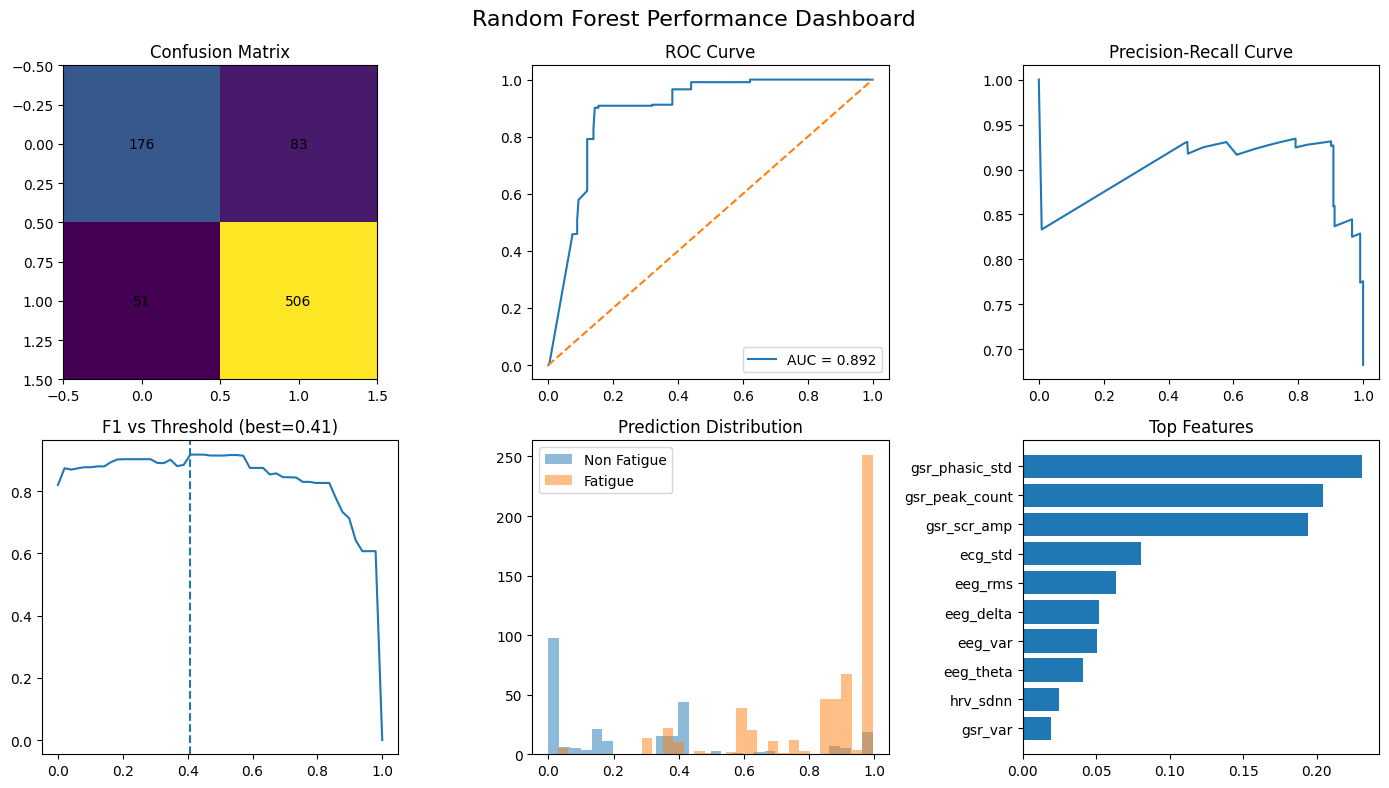

In [78]:
from sklearn.ensemble import RandomForestClassifier


# ── Model ──────────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=3,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)

# ── Predictions ────────────────────────────────────────────────────────────
threshold = 0.40

# Train
y_train_prob = rf.predict_proba(X_train_sc)[:, 1]
y_train_pred = (y_train_prob > threshold).astype(int)

# Test
y_test_prob = rf.predict_proba(X_test_sc)[:, 1]
y_test_pred = (y_test_prob > threshold).astype(int)

# ── Evaluate Train & Test ──────────────────────────────────────────────────
train_metrics = evaluate(y_train, y_train_prob, y_train_pred, "Train")
test_metrics  = evaluate(y_test, y_test_prob, y_test_pred, "Test")
model_results_append(model_results, train_metrics, test_metrics, model_name='Random Forest', mode='ml')
plot_dashboard(test_metrics, y_test_prob, rf, title='Random Forest')

## SVM with RBF kernel


=== Train Evaluation ===
Accuracy  : 0.9270
Precision : 0.9095
Recall    : 0.9847
F1 Score  : 0.9456

 Train Classification Report:
               precision    recall  f1-score   support

 Non Fatigue       0.97      0.82      0.89      1334
     Fatigue       0.91      0.98      0.95      2418

    accuracy                           0.93      3752
   macro avg       0.94      0.90      0.92      3752
weighted avg       0.93      0.93      0.93      3752


=== Test Evaluation ===
Accuracy  : 0.8591
Precision : 0.8289
Recall    : 1.0000
F1 Score  : 0.9064

 Test Classification Report:
               precision    recall  f1-score   support

 Non Fatigue       1.00      0.56      0.71       259
     Fatigue       0.83      1.00      0.91       557

    accuracy                           0.86       816
   macro avg       0.91      0.78      0.81       816
weighted avg       0.88      0.86      0.85       816


=== Summary ===
Best Threshold : 0.306
AUC Score      : 0.913


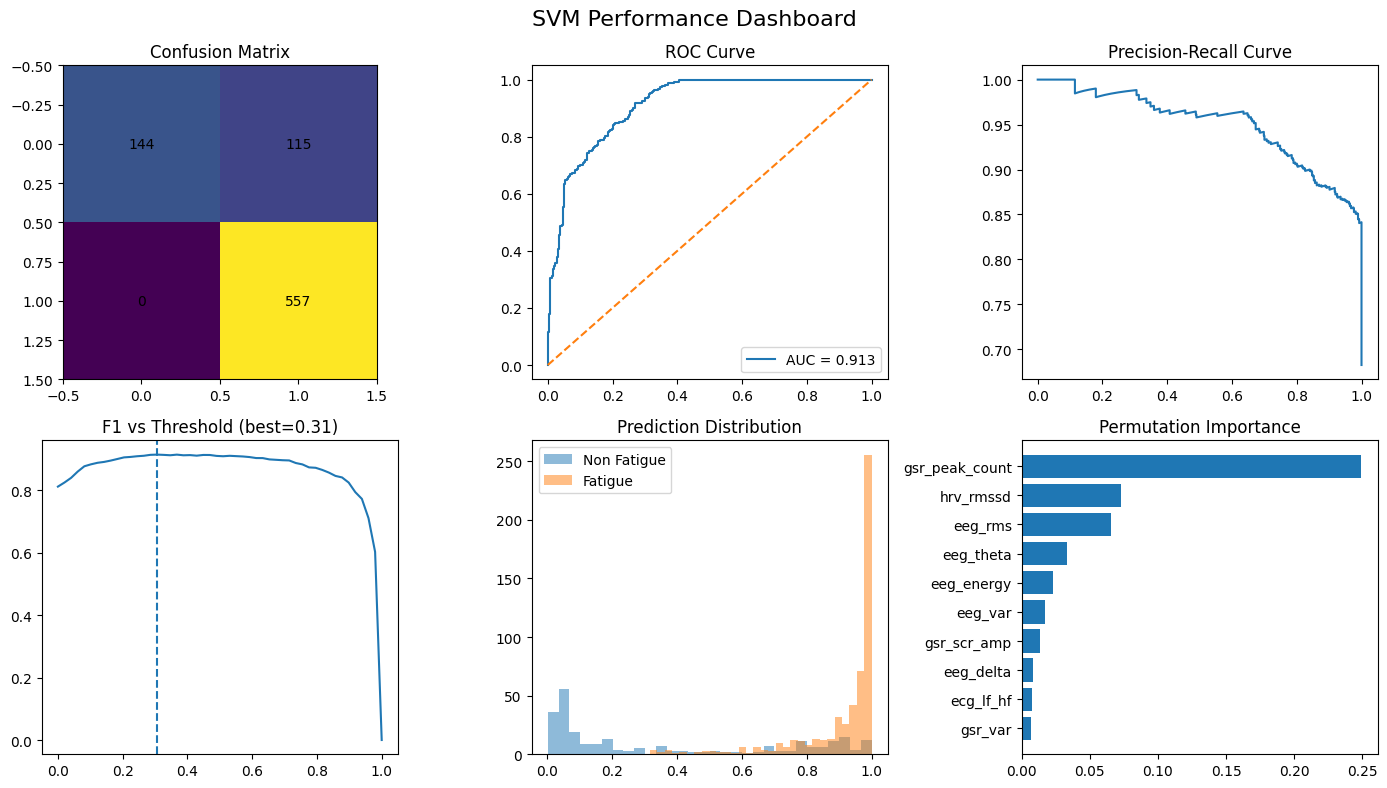

In [34]:
from sklearn.svm import SVC

# ── Scaling ────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Model ──────────────────────────────────────────────────────────────────
svm = SVC(
    kernel='rbf',
    C=2.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm.fit(X_train_sc, y_train)

# ── Predictions ────────────────────────────────────────────────────────────
threshold = 0.22

# Train
y_train_prob = svm.predict_proba(X_train_sc)[:, 1]
y_train_pred = (y_train_prob > threshold).astype(int)

# Test
y_test_prob = svm.predict_proba(X_test_sc)[:, 1]
y_test_pred = (y_test_prob > threshold).astype(int)

# ── Evaluate Train & Test ──────────────────────────────────────────────────
train_metrics = evaluate(y_train, y_train_prob, y_train_pred, "Train")
test_metrics  = evaluate(y_test, y_test_prob, y_test_pred, "Test")
model_results_append(model_results, train_metrics, test_metrics, model_name='SVM', mode='ml')
plot_dashboard(test_metrics, y_test_prob, svm, title='SVM')

## Logistic Regression


=== Train Evaluation ===
Accuracy  : 0.8457
Precision : 0.8133
Recall    : 0.9872
F1 Score  : 0.8918

 Train Classification Report:
               precision    recall  f1-score   support

 Non Fatigue       0.96      0.59      0.73      1334
     Fatigue       0.81      0.99      0.89      2418

    accuracy                           0.85      3752
   macro avg       0.89      0.79      0.81      3752
weighted avg       0.87      0.85      0.83      3752


=== Test Evaluation ===
Accuracy  : 0.8775
Precision : 0.8478
Recall    : 1.0000
F1 Score  : 0.9176

 Test Classification Report:
               precision    recall  f1-score   support

 Non Fatigue       1.00      0.61      0.76       259
     Fatigue       0.85      1.00      0.92       557

    accuracy                           0.88       816
   macro avg       0.92      0.81      0.84       816
weighted avg       0.90      0.88      0.87       816


=== Summary ===
Best Threshold : 0.306
AUC Score      : 0.970


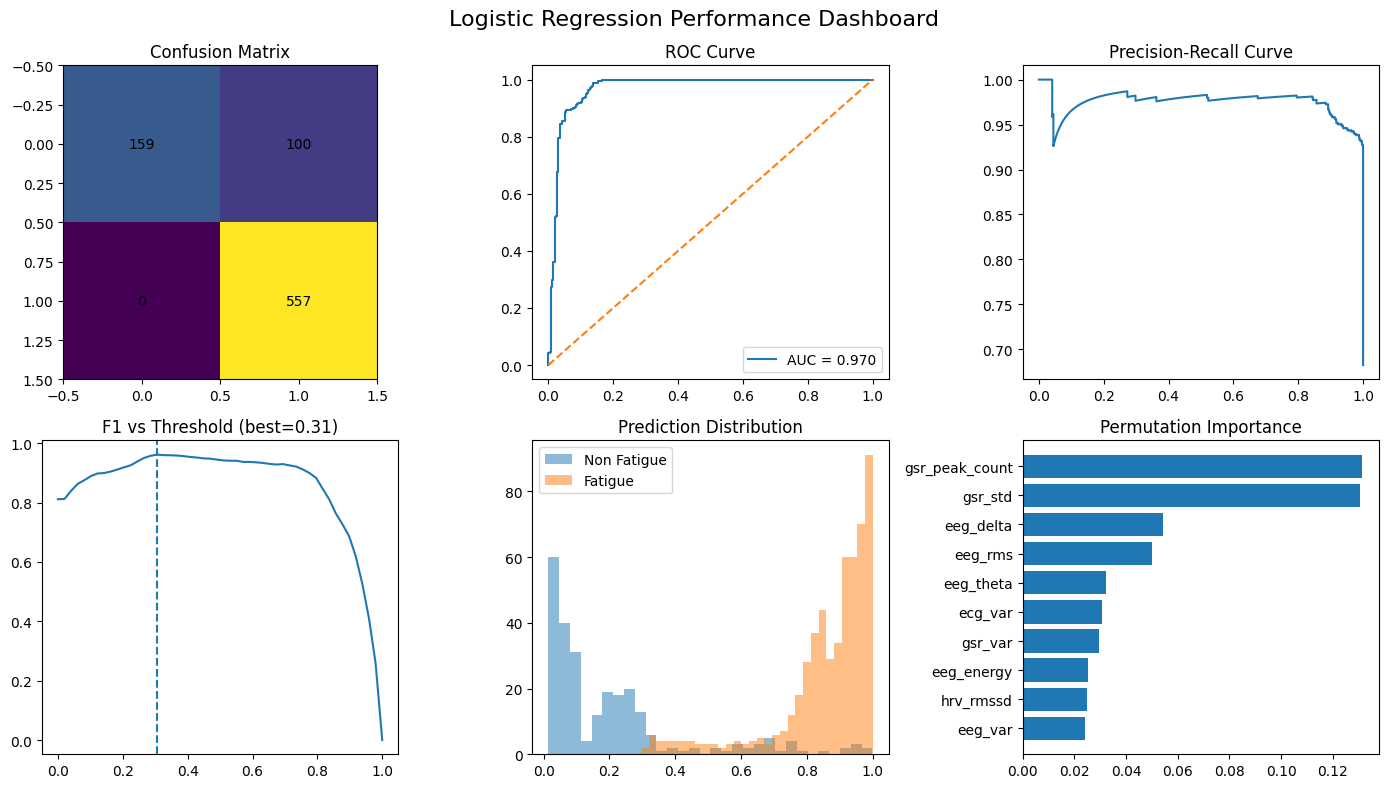

In [81]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr.fit(X_train_sc, y_train)

# ── Predictions ────────────────────────────────────────────────────────────
threshold = 0.2

# Train
y_train_prob = lr.predict_proba(X_train_sc)[:, 1]
y_train_pred = (y_train_prob > threshold).astype(int)

# Test
y_test_prob = lr.predict_proba(X_test_sc)[:, 1]
y_test_pred = (y_test_prob > threshold).astype(int)

# ── Evaluate Train & Test ──────────────────────────────────────────────────
train_metrics = evaluate(y_train, y_train_prob, y_train_pred, "Train")
test_metrics  = evaluate(y_test, y_test_prob, y_test_pred, "Test")
model_results_append(model_results, train_metrics, test_metrics, model_name='Logistic Regression', mode='ml')
plot_dashboard(test_metrics, y_test_prob, lr, title='Logistic Regression')

# Deep Learning Models

## Build sequences with per-worker normalisation

In [36]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ── Config ───────────────────────────────────────────────────────────────────
SEQ_LEN      = 5
CLEAN_COLS   = FEATURE_COLS
N_FEATURES   = len(CLEAN_COLS)
TEST_WORKERS  = [15, 16]
TRAIN_WORKERS = [d for d in feature_matrix['worker'].unique()
                 if d not in TEST_WORKERS]

# ── Binary label ONCE — before anything else ──────────────────────────────────
feature_matrix['label_bin'] = (feature_matrix['label'] > 0).astype(int)

# ── Per-Worker normalisation ──────────────────────────────────────────────────
def normalise_per_worker(df, cols):
    out      = df.copy()
    out[cols] = out[cols].astype('float64')
    for worker_id, grp in df.groupby('worker'):
        mask = out['worker'] == worker_id
        mu   = grp[cols].astype('float64').mean()
        sig  = grp[cols].astype('float64').std().replace(0, 1e-8)
        out.loc[mask, cols] = (
            grp[cols].astype('float64').values - mu.values
        ) / sig.values
    return out

# ── Split raw dataframes ──────────────────────────────────────────────────────
train_raw = feature_matrix[
    feature_matrix['worker'].isin(TRAIN_WORKERS)].reset_index(drop=True)
test_raw  = feature_matrix[
    feature_matrix['worker'].isin(TEST_WORKERS)].reset_index(drop=True)

train_df = normalise_per_worker(train_raw, CLEAN_COLS)
test_df  = normalise_per_worker(test_raw,  CLEAN_COLS)

# ── Global scaler fit on normalised train only ────────────────────────────────
scaler = StandardScaler()
scaler.fit(train_df[CLEAN_COLS].values)

# ── Sequence builder — reads label_bin directly ───────────────────────────────
def build_sequences(df, scaler, seq_len=SEQ_LEN):
    X_seqs, y_seqs = [], []
    for worker_id, grp in df.groupby('worker'):
        grp    = grp.reset_index(drop=True)
        scaled = scaler.transform(grp[CLEAN_COLS].values)
        labels = grp['label_bin'].values          # ← binary directly
        for i in range(seq_len, len(grp)):
            X_seqs.append(scaled[i - seq_len : i])
            y_seqs.append(labels[i])
    return np.array(X_seqs, dtype=np.float32), np.array(y_seqs, dtype=np.int64)

# ── Build sequences ───────────────────────────────────────────────────────────
X_seq_train, y_seq_train = build_sequences(train_df, scaler)
X_seq_test,  y_seq_test  = build_sequences(test_df,  scaler)

# ── Held-out validation worker (worker 12) for EarlyStopping ─────────────────
VAL_WORKER = 12
train_sub  = train_df[train_df['worker'] != VAL_WORKER].reset_index(drop=True)
val_sub    = train_df[train_df['worker'] == VAL_WORKER].reset_index(drop=True)
X_tr,  y_tr  = build_sequences(train_sub, scaler)
X_val, y_val = build_sequences(val_sub,   scaler)

# ── Sanity checks ─────────────────────────────────────────────────────────────
print("=== Sanity Checks ===")
print(f'X_seq_train  : {X_seq_train.shape}')
print(f'X_seq_test   : {X_seq_test.shape}')
print(f'X_tr (no w12): {X_tr.shape}  |  X_val (w12): {X_val.shape}')
print(f'\nTrain  Non Fatigue={(y_seq_train==0).sum()}  Fatigue={(y_seq_train==1).sum()}')
print(f'Test   Non Fatigue={(y_seq_test==0).sum()}   Fatigue={(y_seq_test==1).sum()}')
print(f'Val    Non Fatigue={(y_val==0).sum()}   Fatigue={(y_val==1).sum()}')

if np.isnan(X_seq_train).sum() > 0 or np.isnan(X_seq_test).sum() > 0:
    print("\nWARNING: NaN values detected in sequences!")
    print(f'\nNaN — Train: {np.isnan(X_seq_train).sum()}  Test: {np.isnan(X_seq_test).sum()}')
else:
    print("\nNo NaN values detected in sequences.")

=== Sanity Checks ===
X_seq_train  : (3712, 5, 22)
X_seq_test   : (806, 5, 22)
X_tr (no w12): (3238, 5, 22)  |  X_val (w12): (474, 5, 22)

Train  Non Fatigue=1294  Fatigue=2418
Test   Non Fatigue=249   Fatigue=557
Val    Non Fatigue=191   Fatigue=283

No NaN values detected in sequences.


### Helper functions

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        confusion_matrix, classification_report,
        roc_curve, auc, precision_recall_curve
    )

def evaluate_dl(y_true, y_prob, label="Model"):
    # ── Threshold tuning (F1-based) ─────────────────────────────────────────
    thresholds = np.linspace(0, 1, 100)
    f1_scores = [f1_score(y_true, (y_prob > t).astype(int)) for t in thresholds]

    best_t  = thresholds[np.argmax(f1_scores)]
    best_f1 = np.max(f1_scores)

    y_pred = (y_prob > best_t).astype(int)

    # ── Metrics ────────────────────────────────────────────────────────────
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    print(f"\n=== {label} Evaluation ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"Best Threshold : {best_t:.3f}")

    # ── Class names ────────────────────────────────────────────────────────
    class_names = ["Non Fatigue", "Fatigue"]

    print(f"\n{label} Classification Report:\n",
          classification_report(y_true, y_pred, target_names=class_names))

    # ── Curves ─────────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    pr_precision, pr_recall, _ = precision_recall_curve(y_true, y_prob)

    cm = confusion_matrix(y_true, y_pred)

    return {
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "best_t": best_t,
        "best_f1": best_f1,
        "classification_report": classification_report(
            y_true, y_pred,
            target_names=class_names,
            output_dict=True
        ),
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc,
        "pr_precision": pr_precision,
        "pr_recall": pr_recall,
        "thresholds": thresholds,
        "f1_scores": f1_scores,
        "cm": cm,
        "y_pred": y_pred
    }


def plot_dashboard_dl(metrics, y_true, y_prob, history, title="DL Model"):
    print("\n=== Summary ===")
    print(f"AUC Score      : {metrics['roc_auc']:.3f}")
    print(f"Best Threshold : {metrics['best_t']:.3f}")
    print(f"Best F1 Score  : {metrics['best_f1']:.3f}")

    cm = metrics["cm"]

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))

    # 1. Loss
    ax = axes[0, 0]
    ax.plot(history.history['loss'], label='train')
    ax.plot(history.history['val_loss'], label='val')
    ax.set_title("Loss")
    ax.legend()

    # 2. Accuracy
    ax = axes[0, 1]
    ax.plot(history.history['accuracy'], label='train')
    ax.plot(history.history['val_accuracy'], label='val')
    ax.set_title("Accuracy")
    ax.legend()

    # 3. Confusion Matrix
    ax = axes[0, 2]
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=["Non Fatigue", "Fatigue"],
                yticklabels=["Non Fatigue", "Fatigue"],
                cmap='Blues', ax=ax)
    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    # 4. ROC
    ax = axes[0, 3]
    ax.plot(metrics["fpr"], metrics["tpr"],
            label=f"AUC={metrics['roc_auc']:.3f}")
    ax.plot([0, 1], [0, 1], '--')
    ax.set_title("ROC Curve")
    ax.legend()

    # 5. Precision-Recall
    ax = axes[1, 0]
    ax.plot(metrics["pr_recall"], metrics["pr_precision"])
    ax.set_title("Precision-Recall")

    # 6. F1 vs Threshold
    ax = axes[1, 1]
    ax.plot(metrics["thresholds"], metrics["f1_scores"])
    ax.axvline(metrics["best_t"], color='red', linestyle='--')
    ax.set_title(f"F1 vs Threshold (best={metrics['best_t']:.2f})")

    # 7. Probability Distribution
    ax = axes[1, 2]
    ax.hist(y_prob[y_true == 0], bins=30, alpha=0.5, label='Non Fatigue')
    ax.hist(y_prob[y_true == 1], bins=30, alpha=0.5, label='Fatigue')
    ax.set_title("Probability Distribution")
    ax.legend()

    # 8. Timeline (sequence insight)
    ax = axes[1, 3]
    ax.plot(y_true[:200], label='True')
    ax.plot(metrics["y_pred"][:200], label='Pred', alpha=0.7)
    ax.set_title("Prediction Timeline")
    ax.legend()

    plt.suptitle(f'{title} Performance Dashboard', fontsize=16)
    plt.tight_layout()
    plt.show()


def plot_dashboard_GS(model, history, X_test, y_test, title="Grid Search Model"):
    
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import (
        confusion_matrix, roc_curve, auc,
        precision_recall_curve, f1_score
    )

    # ── Predictions ─────────────────────────────────────────
    y_prob = model.predict(X_test).flatten()

    # ── Threshold tuning ────────────────────────────────────
    thresholds = np.linspace(0, 1, 50)
    f1_scores = [f1_score(y_test, (y_prob > t).astype(int)) for t in thresholds]

    best_t = thresholds[np.argmax(f1_scores)]
    best_f1 = np.max(f1_scores)

    y_pred = (y_prob > best_t).astype(int)

    # ── Metrics ─────────────────────────────────────────────
    cm = confusion_matrix(y_test, y_pred)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_prob)

    print("\n=== Grid Search Model Summary ===")
    print(f"AUC Score      : {roc_auc:.3f}")
    print(f"Best Threshold : {best_t:.3f}")
    print(f"Best F1 Score  : {best_f1:.3f}")

    # ── Plotting ────────────────────────────────────────────
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))

    # 1. Loss
    ax = axes[0, 0]
    ax.plot(history.history['loss'], label='train')
    ax.plot(history.history['val_loss'], label='val')
    ax.set_title("Loss")
    ax.legend()

    # 2. Accuracy
    ax = axes[0, 1]
    ax.plot(history.history['accuracy'], label='train')
    ax.plot(history.history['val_accuracy'], label='val')
    ax.set_title("Accuracy")
    ax.legend()

    # 3. Confusion Matrix
    ax = axes[0, 2]
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=["Non Fatigue", "Fatigue"],
                yticklabels=["Non Fatigue", "Fatigue"],
                cmap='Blues', ax=ax)
    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    # 4. ROC Curve
    ax = axes[0, 3]
    ax.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], '--')
    ax.set_title("ROC Curve")
    ax.legend()

    # 5. Precision-Recall Curve
    ax = axes[1, 0]
    ax.plot(pr_recall, pr_precision)
    ax.set_title("Precision-Recall")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")

    # 6. F1 vs Threshold
    ax = axes[1, 1]
    ax.plot(thresholds, f1_scores)
    ax.axvline(best_t, color='red', linestyle='--')
    ax.set_title(f"F1 vs Threshold (best={best_t:.2f})")

    # 7. Probability Distribution
    ax = axes[1, 2]
    ax.hist(y_prob[y_test == 0], bins=30, alpha=0.5, label='Non Fatigue')
    ax.hist(y_prob[y_test == 1], bins=30, alpha=0.5, label='Fatigue')
    ax.set_title("Probability Distribution")
    ax.legend()

    # 8. Timeline
    ax = axes[1, 3]
    ax.plot(y_test[:200], label='True')
    ax.plot(y_pred[:200], label='Pred', alpha=0.7)
    ax.set_title("Prediction Timeline")
    ax.legend()

    plt.suptitle(f'{title} Performance Dashboard', fontsize=16)
    plt.tight_layout()
    plt.show()

In [38]:
import tensorflow as tf
from tensorflow.keras import backend as K

# To Calculate F1 Score (for DL model evaluation)
def f1_score(y_true, y_pred):
    y_pred = tf.round(y_pred)
    tp = K.sum(K.cast(y_true * y_pred, 'float'))
    fp = K.sum(K.cast((1-y_true) * y_pred, 'float'))
    fn = K.sum(K.cast(y_true * (1-y_pred), 'float'))

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

### Class weights for Class Balancing

In [39]:
# ── Class weights (on X_tr only) ────────────────────────
cw = compute_class_weight(
    'balanced',
    classes=np.array([0, 1]),
    y=y_tr                              
)
class_weight = {0: 1.8, 1: 1.0}        
print(f"Computed weights → Non Fatigue: {cw[0]:.2f}  Fatigue: {cw[1]:.2f}")
print(f"Using weights    → Non Fatigue: 1.8          Fatigue: 1.0")

Computed weights → Non Fatigue: 1.47  Fatigue: 0.76
Using weights    → Non Fatigue: 1.8          Fatigue: 1.0


## Baseline LSTM BINARY

In [64]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from tensorflow_addons.metrics import F1Score

EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 5e-4

os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'
tf.random.set_seed(42)
np.random.seed(42)

# ── Model Architecture  ──────────────────────────────────────
'''lstm_bin = Sequential([
    LSTM(32, input_shape=(SEQ_LEN, N_FEATURES),
         return_sequences=True,
         recurrent_dropout=0.2),
    Dropout(0.4),
    LSTM(16,
         recurrent_dropout=0.2),
    Dropout(0.4),
    Dense(1, activation='sigmoid')      # no Dense(32) — caused overfitting
])'''

lstm_model = Sequential([
    LSTM(32, input_shape=(SEQ_LEN, N_FEATURES),
         return_sequences=True,
         activation='tanh',
         recurrent_activation='sigmoid'),
    Dropout(0.4),
    LSTM(16,
         activation='tanh',
         recurrent_activation='sigmoid'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])


lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall', f1_score]
)

lstm_model.summary()

Model: "sequential_65"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_264 (LSTM)             (None, 5, 32)             7040      
                                                                 
 dropout_332 (Dropout)       (None, 5, 32)             0         
                                                                 
 lstm_265 (LSTM)             (None, 16)                3136      
                                                                 
 dropout_333 (Dropout)       (None, 16)                0         
                                                                 
 dense_304 (Dense)           (None, 1)                 17        
                                                                 
Total params: 10,193
Trainable params: 10,193
Non-trainable params: 0
_________________________________________________________________


In [65]:
# ── Shuffle train subset only ─────────────────────────────────────────────────
idx              = np.random.permutation(len(X_tr))
X_train_shuffled = X_tr[idx]
y_train_shuffled = y_tr[idx]           # ← already binary from Cell 30

# ── Train with worker-12 validation set ──────────────────────────────────────
history_lstm = lstm_model.fit(
    X_train_shuffled, y_train_shuffled,
    # validation_data=(X_val, y_val),    # ← proper held-out worker, not split
    validation_split=0.15,epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

# ── Save immediately after training ──────────────────────────────────────────
lstm_model.save('lstm_binary_best.hdf5')
print("Model saved")

Epoch 1/50
43/43 [==============================] - 7s 64ms/step - loss: 0.7827 - accuracy: 0.7238 - precision: 0.8570 - recall: 0.6986 - f1_score: 0.7680 - val_loss: 0.5619 - val_accuracy: 0.7716 - val_precision: 0.8576 - val_recall: 0.7792 - val_f1_score: 0.8076
Epoch 2/50
43/43 [==============================] - 1s 24ms/step - loss: 0.6255 - accuracy: 0.8107 - precision: 0.9076 - recall: 0.7943 - f1_score: 0.8465 - val_loss: 0.4817 - val_accuracy: 0.7942 - val_precision: 0.8605 - val_recall: 0.8170 - val_f1_score: 0.8319
Epoch 3/50
43/43 [==============================] - 1s 24ms/step - loss: 0.5338 - accuracy: 0.8459 - precision: 0.9062 - recall: 0.8553 - f1_score: 0.8792 - val_loss: 0.4227 - val_accuracy: 0.8333 - val_precision: 0.8665 - val_recall: 0.8801 - val_f1_score: 0.8678
Epoch 4/50
43/43 [==============================] - 1s 24ms/step - loss: 0.4729 - accuracy: 0.8721 - precision: 0.9104 - recall: 0.8944 - f1_score: 0.9010 - val_loss: 0.3854 - val_accuracy: 0.8457 - val_pr

26/26 [==============================] - 0s 7ms/step

=== LSTM Evaluation ===
Accuracy  : 0.8859
Precision : 0.8768
Recall    : 0.9713
F1 Score  : 0.9216
Best Threshold : 0.293

LSTM Classification Report:
               precision    recall  f1-score   support

 Non Fatigue       0.92      0.69      0.79       249
     Fatigue       0.88      0.97      0.92       557

    accuracy                           0.89       806
   macro avg       0.90      0.83      0.86       806
weighted avg       0.89      0.89      0.88       806


=== Summary ===
AUC Score      : 0.901
Best Threshold : 0.293
Best F1 Score  : 0.922


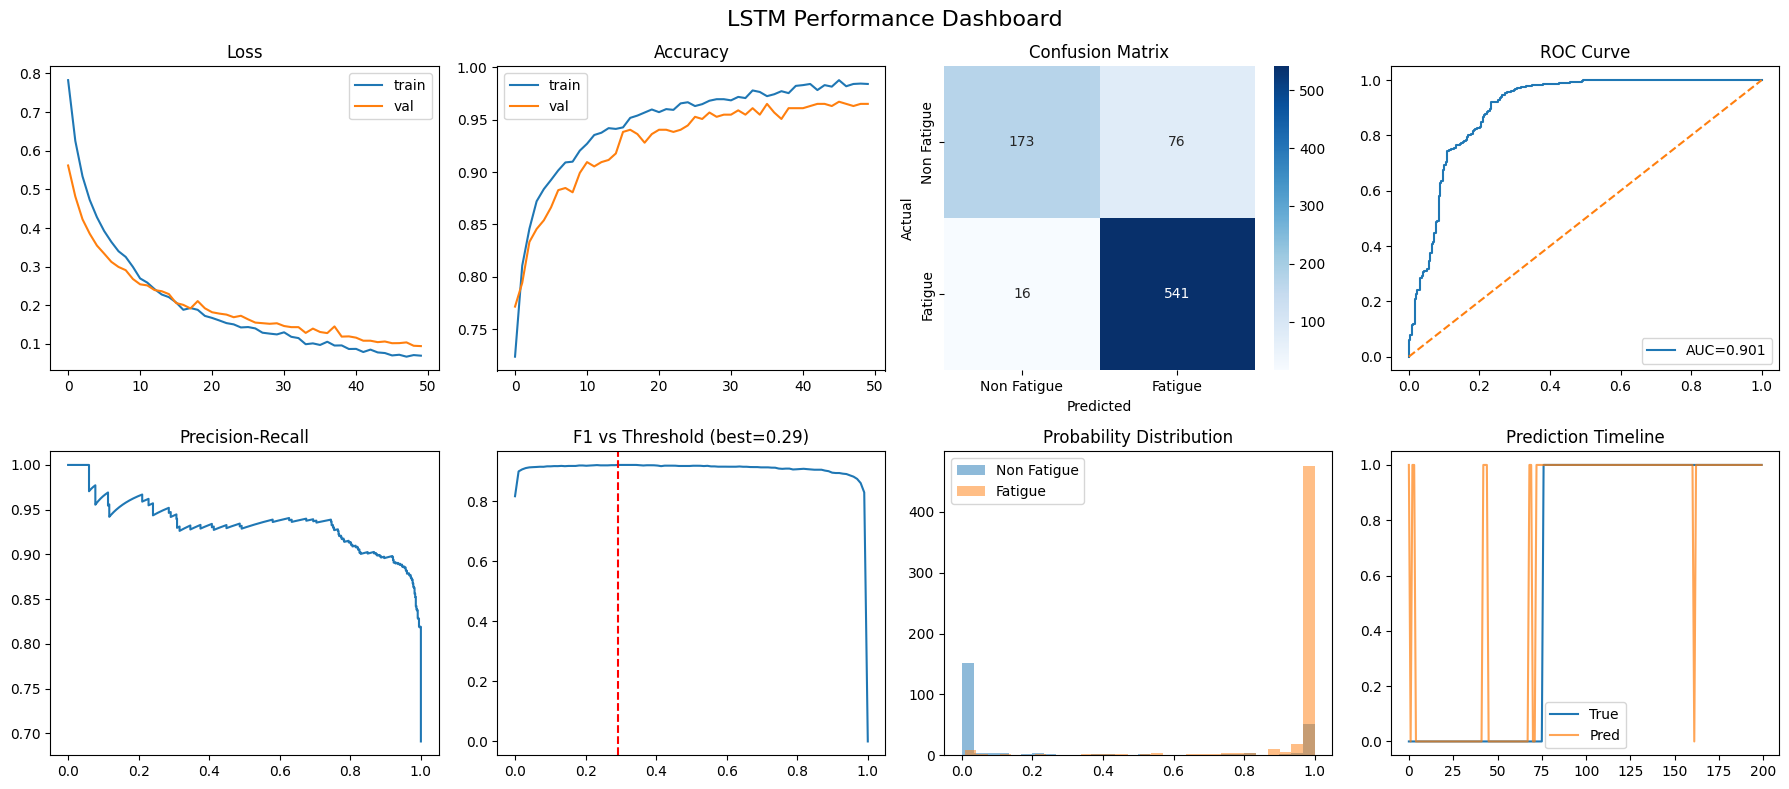

In [67]:
# Predict
y_true = y_seq_test
y_prob = lstm_model.predict(X_seq_test).flatten()

# Evaluate
metrics = evaluate_dl(y_true, y_prob, label="LSTM")
model_results_append(model_results, train_metrics=None, test_metrics=metrics, model_name='baseline_LSTM', mode='dl', history=history_lstm, metrics=metrics)
plot_dashboard_dl(metrics, y_true, y_prob, history_lstm, title="LSTM")

## Temporal Attention LSTM

In [43]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K

tf.random.set_seed(42)
np.random.seed(42)

# ── Convert labels to binary ───────────────────────────────
y_train_bin = (y_seq_train > 0).astype(int)

# ── Class weights ──────────────────────────────────────────
class_weight = {0: 1.8, 1: 1.0}

# ── Custom Attention Layer ─────────────────────────────────
class AttentionLayer(Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True
        )
        self.b = self.add_weight(
            shape=(input_shape[1], 1),
            initializer='zeros',
            trainable=True
        )

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)   # (batch, time, 1)
        a = K.softmax(e, axis=1)                # attention weights
        context = x * a
        return K.sum(context, axis=1)           # (batch, features)

# ── Model ─────────────────────────────────────────────────
SEQ_LEN = X_seq_train.shape[1]
N_FEATURES = X_seq_train.shape[2]

inputs = Input(shape=(SEQ_LEN, N_FEATURES))

x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.3)(x)

x = LSTM(32, return_sequences=True)(x)
x = Dropout(0.3)(x)

#  Attention
context = AttentionLayer()(x)

x = Dense(32, activation='relu')(context)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

tan_v1_model = Model(inputs, output)

# ── FIXED compile  ───────────────────────────
tan_v1_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall', f1_score]
)
tan_v1_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 5, 22)]           0         
                                                                 
 lstm_2 (LSTM)               (None, 5, 64)             22272     
                                                                 
 dropout_2 (Dropout)         (None, 5, 64)             0         
                                                                 
 lstm_3 (LSTM)               (None, 5, 32)             12416     
                                                                 
 dropout_3 (Dropout)         (None, 5, 32)             0         
                                                                 
 attention_layer (AttentionL  (None, 32)               37        
 ayer)                                                           
                                                             

Epoch 1/100
50/50 [==============================] - 4s 30ms/step - loss: 0.7645 - accuracy: 0.7794 - precision: 0.8476 - recall: 0.8063 - f1_score: 0.8262 - val_loss: 0.4870 - val_accuracy: 0.7810 - val_precision: 0.8453 - val_recall: 0.8127 - val_f1_score: 0.8227
Epoch 2/100
50/50 [==============================] - 1s 13ms/step - loss: 0.5415 - accuracy: 0.8051 - precision: 0.8871 - recall: 0.8029 - f1_score: 0.8416 - val_loss: 0.4111 - val_accuracy: 0.8115 - val_precision: 0.8564 - val_recall: 0.8540 - val_f1_score: 0.8517
Epoch 3/100
50/50 [==============================] - 1s 13ms/step - loss: 0.4457 - accuracy: 0.8643 - precision: 0.9074 - recall: 0.8818 - f1_score: 0.8920 - val_loss: 0.3547 - val_accuracy: 0.8618 - val_precision: 0.8886 - val_recall: 0.9008 - val_f1_score: 0.8928
Epoch 4/100
50/50 [==============================] - 1s 14ms/step - loss: 0.3975 - accuracy: 0.8872 - precision: 0.9208 - recall: 0.9046 - f1_score: 0.9130 - val_loss: 0.3132 - val_accuracy: 0.8833 - va

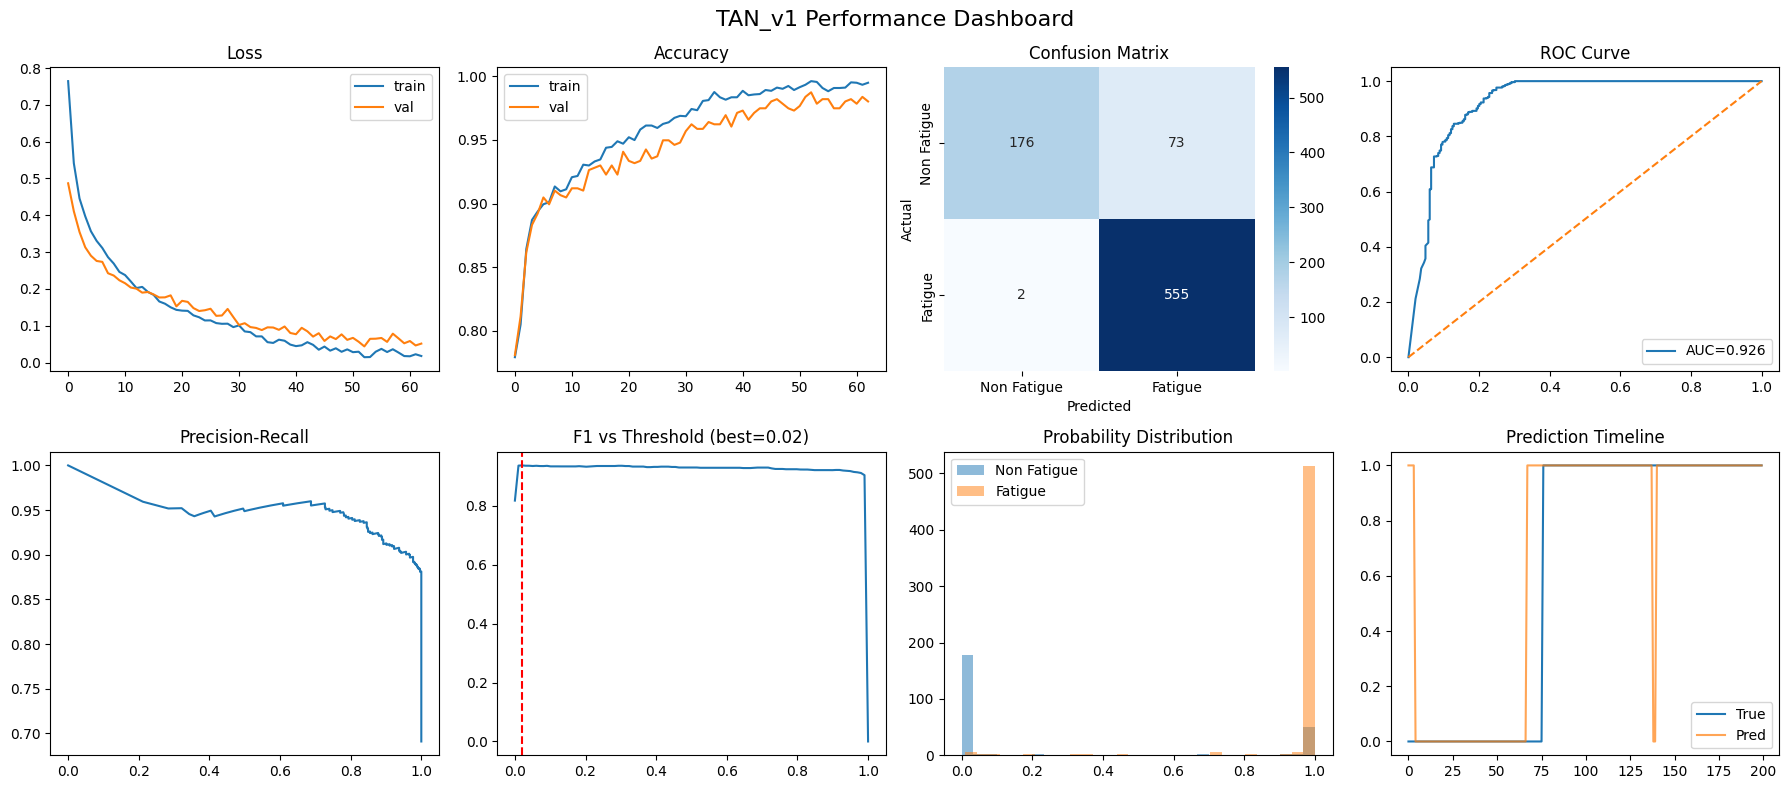

In [44]:
# ── Shuffle ────────────────────────────────────────────────
idx = np.random.permutation(len(X_seq_train))
X_train_shuffled = X_seq_train[idx]
y_train_shuffled = y_train_bin[idx]

# ── Train ─────────────────────────────────────────────────
history_attn = tan_v1_model.fit(
    X_train_shuffled, y_train_shuffled,
    validation_split=0.15,
    epochs=100,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

# Predict
y_true = y_seq_test
y_prob = tan_v1_model.predict(X_seq_test).flatten()

# Evaluate
metrics = evaluate_dl(y_true, y_prob, label="TAN_v1")
model_results_append(model_results, train_metrics=None, test_metrics=metrics, model_name='TAN_v1', mode='dl', history=history_attn, metrics=metrics)
plot_dashboard_dl(metrics, y_true, y_prob, history_attn, title="TAN_v1")

#### Grid Search for TAN(LSTM+self_attn)


Testing: 64-32, d=0.2, lr=0.0005, batch=32
Epoch 1/40
99/99 [==============================] - 5s 21ms/step - loss: 0.5084 - accuracy: 0.8076 - precision: 0.8489 - recall: 0.8707 - f1_score: 0.8582 - val_loss: 0.5514 - val_accuracy: 0.7702 - val_precision: 0.7370 - val_recall: 0.8516 - val_f1_score: 0.4432
Epoch 2/40
99/99 [==============================] - 1s 14ms/step - loss: 0.3190 - accuracy: 0.8773 - precision: 0.8987 - recall: 0.9227 - f1_score: 0.9081 - val_loss: 0.5097 - val_accuracy: 0.8007 - val_precision: 0.7606 - val_recall: 0.8869 - val_f1_score: 0.4571
Epoch 3/40
99/99 [==============================] - 1s 15ms/step - loss: 0.2662 - accuracy: 0.8976 - precision: 0.9118 - recall: 0.9396 - f1_score: 0.9236 - val_loss: 0.5623 - val_accuracy: 0.7846 - val_precision: 0.7604 - val_recall: 0.8410 - val_f1_score: 0.4271
Epoch 4/40
99/99 [==============================] - 1s 14ms/step - loss: 0.2297 - accuracy: 0.9132 - precision: 0.9209 - recall: 0.9536 - f1_score: 0.9368 - val_

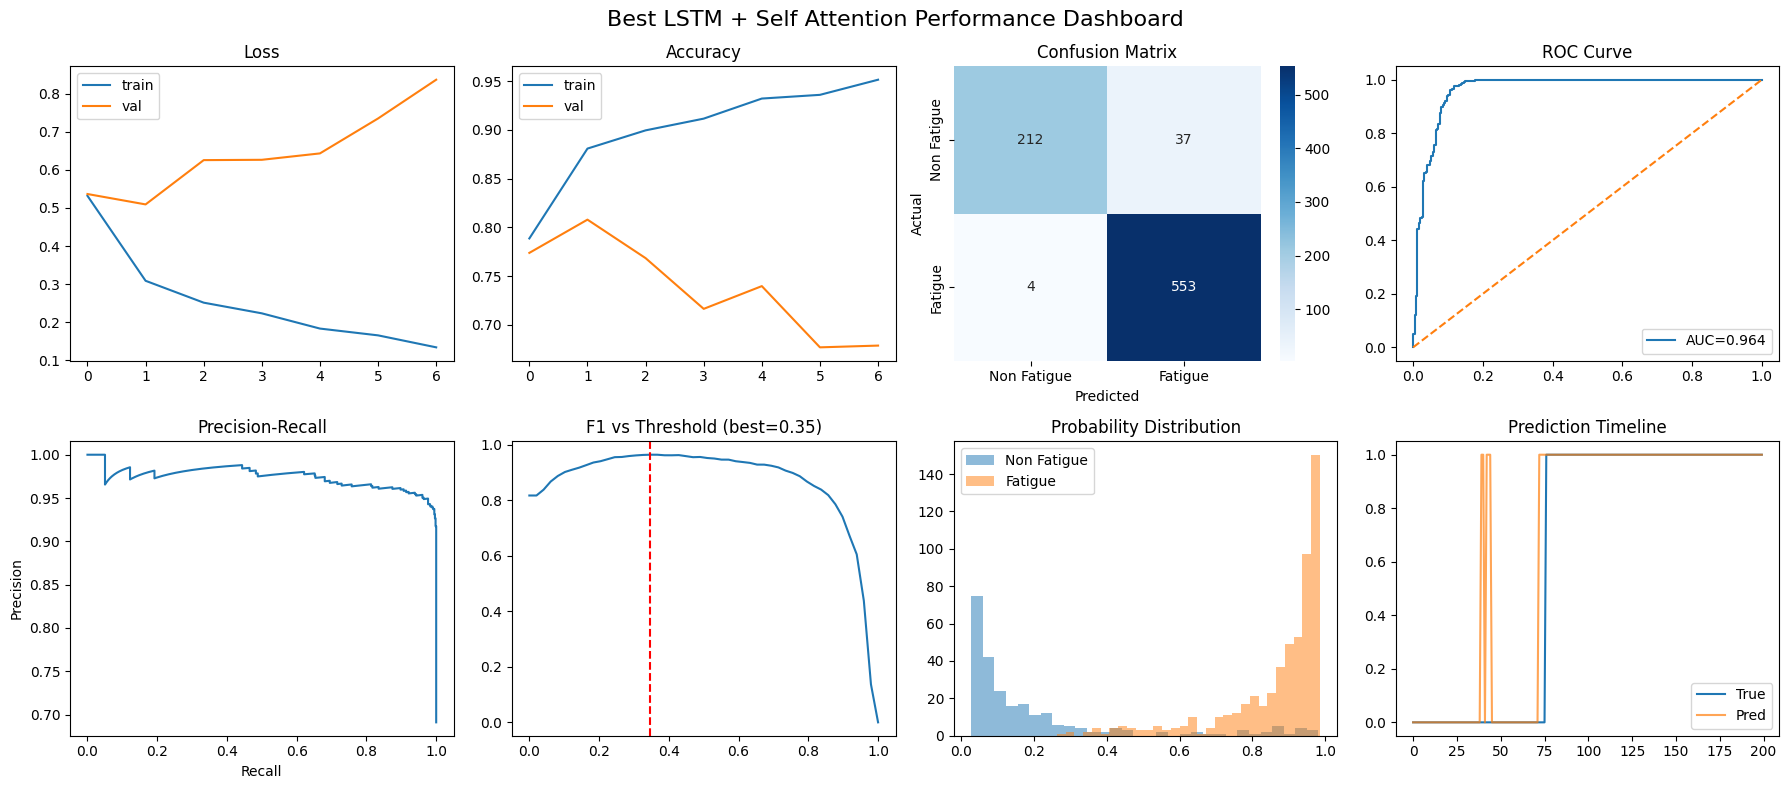

In [45]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import tensorflow.keras.backend as K

tf.random.set_seed(42)
np.random.seed(42)

# ── Binary labels ─────────────────────────────────────────
y_train_bin = (y_seq_train > 0).astype(int)
y_test_bin  = (y_seq_test  > 0).astype(int)

# ── Attention Layer ───────────────────────────────────────
class AttentionLayer(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), initializer='random_normal')
        self.b = self.add_weight(shape=(input_shape[1], 1), initializer='zeros')

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        return K.sum(x * a, axis=1)

# ── Grid ─────────────────────────────────────────────────
param_grid = {
    "lstm1": [64, 128],
    "lstm2": [32, 64],
    "dropout": [0.2, 0.3],
    "lr": [5e-4, 1e-3],
    "batch": [32, 64]
}

results = []

best_model = None
best_history = None
best_f1 = 0
best_params = None

def f1_score(y_true, y_pred):
    y_pred = tf.round(y_pred)
    tp = K.sum(K.cast(y_true * y_pred, 'float'))
    fp = K.sum(K.cast((1-y_true) * y_pred, 'float'))
    fn = K.sum(K.cast(y_true * (1-y_pred), 'float'))

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

# ── Grid Search ──────────────────────────────────────────
for lstm1 in param_grid["lstm1"]:
    for lstm2 in param_grid["lstm2"]:
        for dropout in param_grid["dropout"]:
            for lr in param_grid["lr"]:
                for batch in param_grid["batch"]:

                    print(f"\nTesting: {lstm1}-{lstm2}, d={dropout}, lr={lr}, batch={batch}")

                    # ── Model ───────────────────────
                    inputs = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]))

                    x = LSTM(lstm1, return_sequences=True)(inputs)
                    x = Dropout(dropout)(x)

                    x = LSTM(lstm2, return_sequences=True)(x)
                    x = Dropout(dropout)(x)

                    context = AttentionLayer()(x)

                    x = Dense(32, activation='relu')(context)
                    x = Dropout(dropout)(x)

                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs, output)

                    model.compile(
                        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                        loss='binary_crossentropy',
                        metrics=[
                            'accuracy', 'Precision', 'Recall', f1_score
                        ]
                    )

                    # ── Training ────────────────────
                    history = model.fit(
                        X_seq_train, y_train_bin,
                        validation_split=0.15,
                        epochs=40,
                        batch_size=batch,
                        verbose=1,
                        callbacks=[
                            EarlyStopping(
                                monitor='val_loss',
                                patience=5,
                                restore_best_weights=True
                            )
                        ]
                    )

                    # ── Predictions ─────────────────
                    y_prob = model.predict(X_seq_test).flatten()

                    thresholds = np.linspace(0, 1, 50)
                    f1_scores = [f1_score(y_test_bin, (y_prob > t).astype(int)) for t in thresholds]

                    best_t = thresholds[np.argmax(f1_scores)]
                    y_pred = (y_prob > best_t).astype(int)

                    # ── Metrics ─────────────────────
                    test_f1 = f1_score(y_test_bin, y_pred)
                    test_acc = accuracy_score(y_test_bin, y_pred)
                    test_precision = precision_score(y_test_bin, y_pred)
                    test_recall = recall_score(y_test_bin, y_pred)

                    train_acc = float(history.history['accuracy'][-1])
                    val_acc   = float(history.history['val_accuracy'][-1])

                    print(f" Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Test F1: {test_f1:.3f}")

                    # ── Store results ───────────────
                    results.append({
                        "lstm1": lstm1,
                        "lstm2": lstm2,
                        "dropout": dropout,
                        "lr": lr,
                        "batch": batch,
                        "train_acc": train_acc,
                        "val_acc": val_acc,
                        "test_f1": test_f1,
                        "test_acc": test_acc
                    })

                    # ── Best Model Tracking ─────────
                    if test_f1 > best_f1:
                        best_f1 = test_f1
                        best_model = model
                        best_history = history
                        best_params = {
                            "lstm1": lstm1,
                            "lstm2": lstm2,
                            "dropout": dropout,
                            "lr": lr,
                            "batch": batch
                        }

                        best_metrics = {
                            "acc": test_acc,
                            "precision": test_precision,
                            "recall": test_recall,
                            "f1": test_f1,
                            "best_t": best_t,
                            "best_f1": test_f1,
                            "thresholds": thresholds,
                            "f1_scores": f1_scores,
                            "y_pred": y_pred
                        }

# ── Results ──────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values(by="test_f1", ascending=False)

print("\nTOP CONFIGS:")
print(results_df.head(10))

print("\nBest Params:", best_params)
print("Best F1:", best_f1)

# ── Store in global model table ──────────────────────────
model_results_append(
    model_results,
    model_name="LSTM_SelfAttention",
    mode='dl',
    history=best_history,
    metrics=best_metrics
)

# ── Plot dashboard ───────────────────────────────────────
plot_dashboard_GS(
    best_model,
    best_history,
    X_seq_test,
    y_test_bin,
    title="Best LSTM + Self Attention"
)

##  TAN Model (LSTM + Self Attention + General Attention)

In [46]:
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout,
    Layer, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K

tf.random.set_seed(42)
np.random.seed(42)

# ── Convert labels to binary ───────────────────────────────
y_train_bin = (y_seq_train > 0).astype(int)

# ── Class weights ────────────────────────────────────────────
class_weight = {0: 1.8, 1: 1.0}

# ── Self-Attention Layer ──────────────────────────────────
class SelfAttention(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        context = x * a
        return K.sum(context, axis=1)

# ── General Attention Layer ───────────────────────────────
class GeneralAttention(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]),
                                 initializer='random_normal',
                                 trainable=True)

    def call(self, x):
        score = K.batch_dot(x, K.dot(x, self.W), axes=[2,2])
        weights = K.softmax(score, axis=1)
        context = K.batch_dot(weights, x)
        return K.sum(context, axis=1)

# ── Model ───────────────────────────────────────────────────
SEQ_LEN = X_seq_train.shape[1]
N_FEATURES = X_seq_train.shape[2]

inputs = Input(shape=(SEQ_LEN, N_FEATURES))

# LSTM backbone
x = LSTM(128, return_sequences=True)(inputs)
x = Dropout(0.3)(x)

x = LSTM(32, return_sequences=True)(x)
x = Dropout(0.3)(x)

# Dual Attention
self_att = SelfAttention()(x)
gen_att  = GeneralAttention()(x)

# Concatenate both attentions
combined = Concatenate()([self_att, gen_att])

# Dense head
x = Dense(64, activation='relu')(combined)
x = Dropout(0.3)(x)

x = Dense(32, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

TAN_v2_model = Model(inputs, output)

TAN_v2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall', f1_score]
)

TAN_v2_model.summary()

Model: "model_33"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_34 (InputLayer)          [(None, 5, 22)]      0           []                               
                                                                                                  
 lstm_68 (LSTM)                 (None, 5, 128)       77312       ['input_34[0][0]']               
                                                                                                  
 dropout_101 (Dropout)          (None, 5, 128)       0           ['lstm_68[0][0]']                
                                                                                                  
 lstm_69 (LSTM)                 (None, 5, 32)        20608       ['dropout_101[0][0]']            
                                                                                           

In [47]:
# ── Shuffle ─────────────────────────────────────────────────
idx = np.random.permutation(len(X_seq_train))
X_train_shuffled = X_seq_train[idx]
y_train_shuffled = y_train_bin[idx]

# ── Train ───────────────────────────────────────────────────
history_TAN_v2 = TAN_v2_model.fit(
    X_train_shuffled, y_train_shuffled,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ],
    verbose=1
)


# TOP CONFIGS:
#     lstm1  lstm2  dropout      lr  batch        f1       acc  threshold
# 5      64     32      0.3  0.0005     64  0.960276  0.942928   0.285714

Epoch 1/100
99/99 [==============================] - 6s 23ms/step - loss: 0.5241 - accuracy: 0.8368 - precision: 0.8986 - recall: 0.8448 - f1_score: 0.8678 - val_loss: 0.3526 - val_accuracy: 0.8671 - val_precision: 0.8833 - val_recall: 0.9174 - val_f1_score: 0.9014
Epoch 2/100
99/99 [==============================] - 1s 14ms/step - loss: 0.3868 - accuracy: 0.8891 - precision: 0.9256 - recall: 0.9022 - f1_score: 0.9123 - val_loss: 0.3002 - val_accuracy: 0.8869 - val_precision: 0.9076 - val_recall: 0.9201 - val_f1_score: 0.9149
Epoch 3/100
99/99 [==============================] - 1s 14ms/step - loss: 0.3436 - accuracy: 0.8935 - precision: 0.9313 - recall: 0.9032 - f1_score: 0.9146 - val_loss: 0.2621 - val_accuracy: 0.9084 - val_precision: 0.9286 - val_recall: 0.9311 - val_f1_score: 0.9300
Epoch 4/100
99/99 [==============================] - 1s 14ms/step - loss: 0.3128 - accuracy: 0.9036 - precision: 0.9455 - recall: 0.9041 - f1_score: 0.9232 - val_loss: 0.2540 - val_accuracy: 0.8995 - va

26/26 [==============================] - 1s 5ms/step

=== TAN_v2 Evaluation ===
Accuracy  : 0.9156
Precision : 0.9123
Recall    : 0.9713
F1 Score  : 0.9409
Best Threshold : 0.162

TAN_v2 Classification Report:
               precision    recall  f1-score   support

 Non Fatigue       0.92      0.79      0.85       249
     Fatigue       0.91      0.97      0.94       557

    accuracy                           0.92       806
   macro avg       0.92      0.88      0.90       806
weighted avg       0.92      0.92      0.91       806


=== Summary ===
AUC Score      : 0.923
Best Threshold : 0.162
Best F1 Score  : 0.941


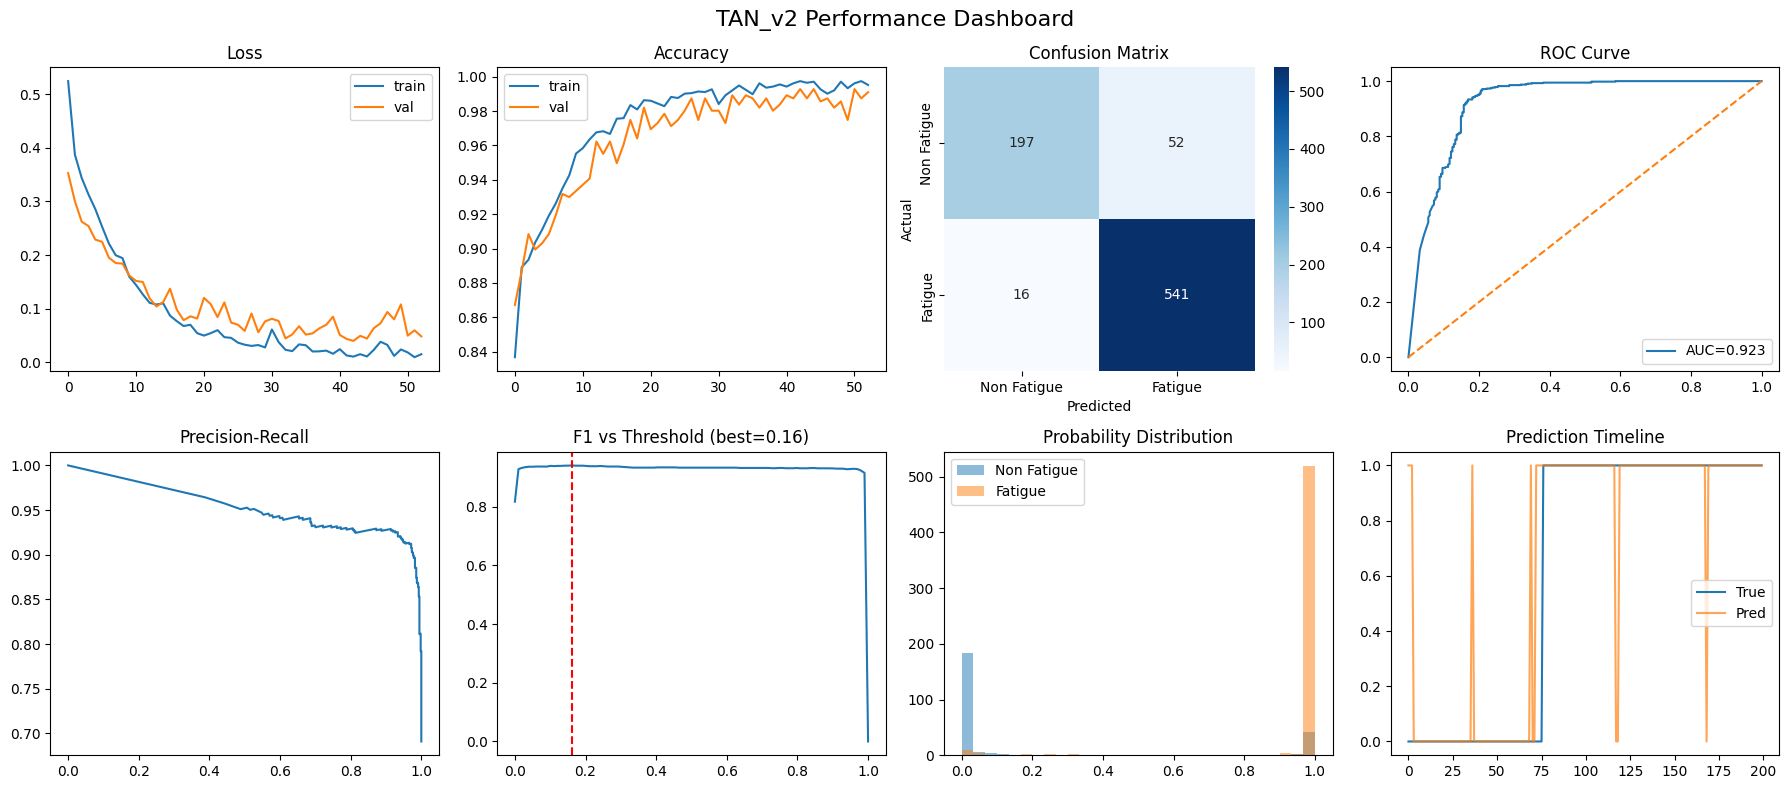

In [48]:
# Predict
y_true = y_seq_test
y_prob = TAN_v2_model.predict(X_seq_test).flatten()

# Evaluate
metrics = evaluate_dl(y_true, y_prob, label="TAN_v2")
model_results_append(model_results, train_metrics=None, test_metrics=metrics, model_name='TAN_v2', 
                     mode='dl', history=history_TAN_v2, metrics=metrics)
plot_dashboard_dl(metrics, y_true, y_prob, history_TAN_v2, title="TAN_v2")

### Grid Search

In [49]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Layer, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import tensorflow.keras.backend as K

tf.random.set_seed(42)
np.random.seed(42)

# ── Binary labels ───────────────────────────────────────────
y_train_bin = (y_seq_train > 0).astype(int)
y_test_bin  = (y_seq_test  > 0).astype(int)

# ── Attention Layers ────────────────────────────────────────
class SelfAttention(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), initializer='random_normal')
        self.b = self.add_weight(shape=(input_shape[1], 1), initializer='zeros')

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        return K.sum(x * a, axis=1)

class GeneralAttention(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]), initializer='random_normal')

    def call(self, x):
        score = K.batch_dot(x, K.dot(x, self.W), axes=[2,2])
        weights = K.softmax(score, axis=1)
        context = K.batch_dot(weights, x)
        return K.sum(context, axis=1)

# To Calculate F1 Score (for DL model evaluation)
def f1_score(y_true, y_pred):
    y_pred = tf.round(y_pred)
    tp = K.sum(K.cast(y_true * y_pred, 'float'))
    fp = K.sum(K.cast((1-y_true) * y_pred, 'float'))
    fn = K.sum(K.cast(y_true * (1-y_pred), 'float'))

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    return 2*((precision*recall)/(precision+recall+K.epsilon()))


#Best Params: {'lstm1': 64, 'lstm2': 32, 'dropout': 0.2, 'lr': 0.0005, 'batch': 64}
# ── Hyperparameter Grid ─────────────────────────────────────
param_grid = {
    "lstm1": [64, 128],
    "lstm2": [32, 64],
    "dropout": [0.2, 0.3],
    "lr": [5e-4, 1e-3],
    "batch": [32, 64]
}

results = []
best_model = None
best_history = None
best_metrics = None
best_params = None
best_f1 = 0

# ── Grid Search ─────────────────────────────────────────────
for lstm1 in param_grid["lstm1"]:
    for lstm2 in param_grid["lstm2"]:
        for dropout in param_grid["dropout"]:
            for lr in param_grid["lr"]:
                for batch in param_grid["batch"]:

                    print(f"\nTesting: {lstm1}-{lstm2}, d={dropout}, lr={lr}, batch={batch}")

                    # ── Model ─────────────────────────
                    inputs = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]))
                    x = LSTM(lstm1, return_sequences=True)(inputs)
                    x = Dropout(dropout)(x)
                    x = LSTM(lstm2, return_sequences=True)(x)
                    x = Dropout(dropout)(x)

                    self_att = SelfAttention()(x)
                    gen_att  = GeneralAttention()(x)
                    combined = Concatenate()([self_att, gen_att])

                    x = Dense(64, activation='relu')(combined)
                    x = Dropout(dropout)(x)
                    x = Dense(32, activation='relu')(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs, output)

                    model.compile(
                        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                        loss='binary_crossentropy',
                        metrics=['accuracy', 'Precision', 'Recall', f1_score]
                    )

                    # ── Shuffle ───────────────────────
                    idx = np.random.permutation(len(X_seq_train))
                    X_train_shuffled = X_seq_train[idx]
                    y_train_shuffled = y_train_bin[idx]

                    # ── Train ─────────────────────────
                    history = model.fit(
                        X_train_shuffled, y_train_shuffled,
                        validation_split=0.15,
                        epochs=50,
                        batch_size=batch,
                        verbose=1,
                        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
                    )

                    # ── TEST PREDICTION ───────────────
                    y_prob_test = model.predict(X_seq_test).flatten()

                    thresholds = np.linspace(0, 1, 50)
                    f1_scores = [f1_score(y_test_bin, (y_prob_test > t).astype(int)) for t in thresholds]

                    best_t = thresholds[np.argmax(f1_scores)]
                    y_pred_test = (y_prob_test > best_t).astype(int)

                    # ── TEST METRICS ──────────────────
                    test_f1 = f1_score(y_test_bin, y_pred_test)
                    test_acc = accuracy_score(y_test_bin, y_pred_test)
                    test_precision = precision_score(y_test_bin, y_pred_test)
                    test_recall = recall_score(y_test_bin, y_pred_test)

                    # ── TRAIN METRICS ─────────────────
                    train_acc = float(history.history['accuracy'][-1])
                    val_acc   = float(history.history['val_accuracy'][-1])

                    print(f" Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Test F1: {test_f1:.3f}")

                    # ── Store results ─────────────────
                    results.append({
                        "lstm1": lstm1,
                        "lstm2": lstm2,
                        "dropout": dropout,
                        "lr": lr,
                        "batch": batch,
                        "train_acc": train_acc,
                        "val_acc": val_acc,
                        "test_f1": test_f1,
                        "test_acc": test_acc,
                        "threshold": best_t
                    })

                    # ── Save Best Model ───────────────
                    if test_f1 > best_f1:
                        best_f1 = test_f1
                        best_model = model
                        best_history = history
                        best_params = {
                            "lstm1": lstm1,
                            "lstm2": lstm2,
                            "dropout": dropout,
                            "lr": lr,
                            "batch": batch
                        }

                        best_metrics = {
                            "acc": test_acc,
                            "precision": test_precision,
                            "recall": test_recall,
                            "f1": test_f1,
                            "best_t": best_t,
                            "best_f1": test_f1,
                            "roc_auc": None,
                            "fpr": None,
                            "tpr": None,
                            "pr_precision": None,
                            "pr_recall": None,
                            "thresholds": thresholds,
                            "f1_scores": f1_scores,
                            "cm": None,
                            "y_pred": y_pred_test
                        }

# ── Results Summary ─────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values(by="test_f1", ascending=False)

print("\nTOP CONFIGS:")
print(results_df.head(10))

print(f"\nBEST F1: {best_f1:.3f}")
print("Best Params:", best_params)

# ── Append to Global Model Table ────────────────────────────
model_results_append(
    model_results,
    model_name="TAN_LSTM_DAN",
    mode='dl',
    history=best_history,
    metrics=best_metrics
)

# ── Dashboard Plot ──────────────────────────────────────────
y_prob_best = best_model.predict(X_seq_test).flatten()
#Best Params: {'lstm1': 64, 'lstm2': 32, 'dropout': 0.2, 'lr': 0.0005, 'batch': 64}


Testing: 64-32, d=0.2, lr=0.0005, batch=32
Epoch 1/50
99/99 [==============================] - 5s 21ms/step - loss: 0.4460 - accuracy: 0.8127 - precision: 0.8801 - recall: 0.8248 - f1_score: 0.8429 - val_loss: 0.3765 - val_accuracy: 0.8510 - val_precision: 0.8535 - val_recall: 0.9311 - val_f1_score: 0.8904
Epoch 2/50
99/99 [==============================] - 1s 14ms/step - loss: 0.3084 - accuracy: 0.8761 - precision: 0.8870 - recall: 0.9280 - f1_score: 0.9052 - val_loss: 0.3184 - val_accuracy: 0.8743 - val_precision: 0.8786 - val_recall: 0.9366 - val_f1_score: 0.9080
Epoch 3/50
99/99 [==============================] - 1s 14ms/step - loss: 0.2646 - accuracy: 0.8894 - precision: 0.8990 - recall: 0.9353 - f1_score: 0.9142 - val_loss: 0.2849 - val_accuracy: 0.8815 - val_precision: 0.8837 - val_recall: 0.9421 - val_f1_score: 0.9130
Epoch 4/50
99/99 [==============================] - 1s 13ms/step - loss: 0.2423 - accuracy: 0.8989 - precision: 0.9129 - recall: 0.9338 - f1_score: 0.9222 - val_

26/26 [==============================] - 0s 3ms/step

=== Grid Search Model Summary ===
AUC Score      : 0.926
Best Threshold : 0.286
Best F1 Score  : 0.956


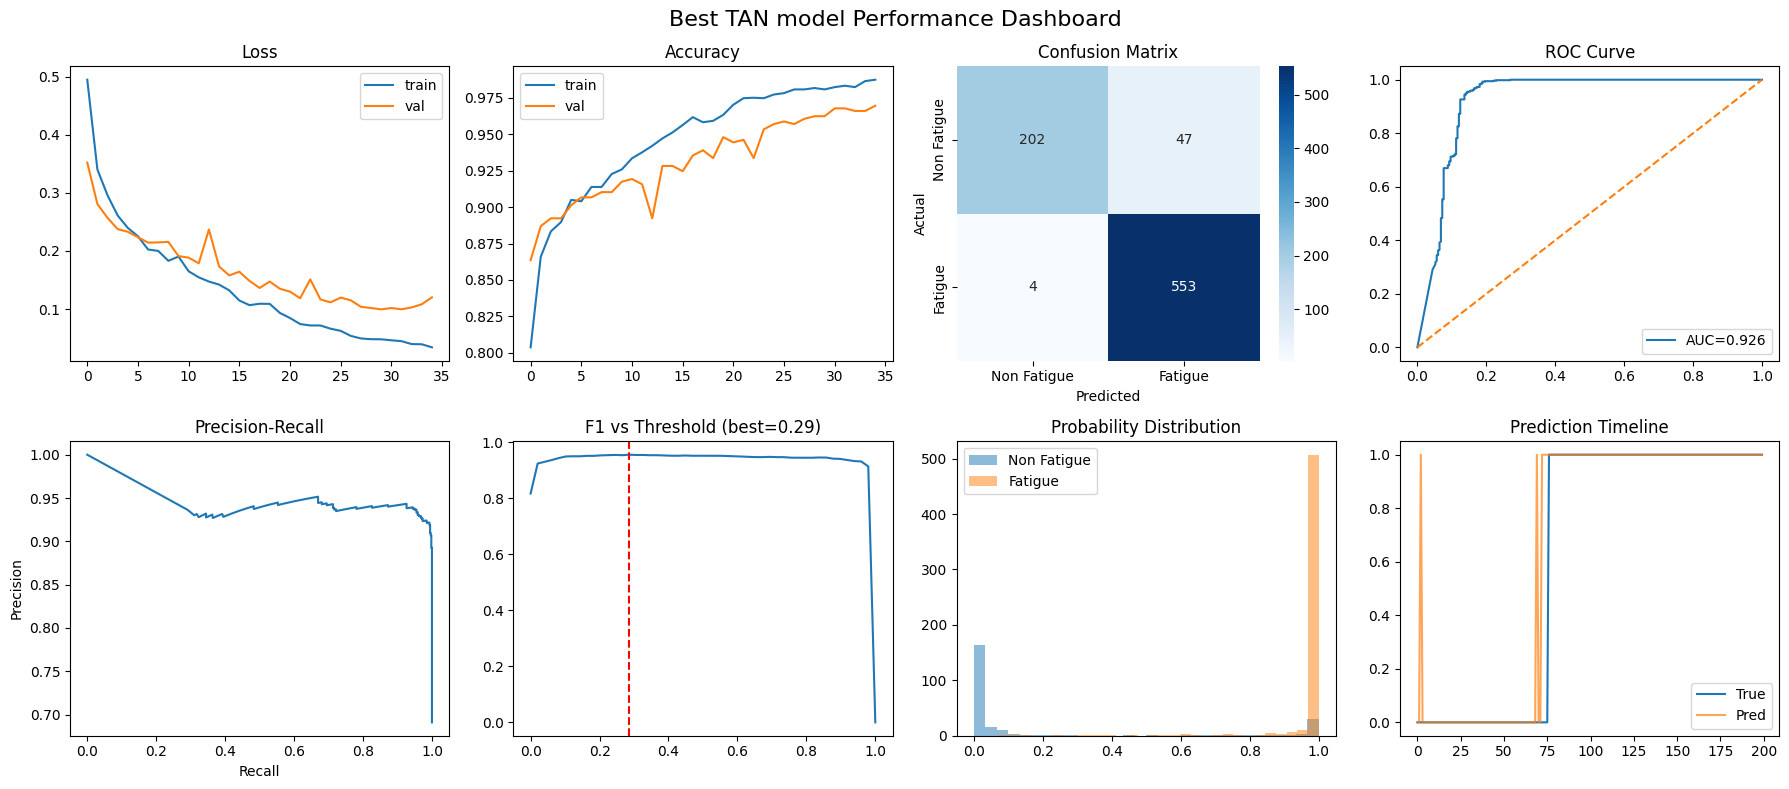

In [50]:
plot_dashboard_GS(best_model, best_history, X_seq_test, y_test_bin, title="Best TAN model")

## CGAN+LSTM

In [51]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, LeakyReLU,
                                        BatchNormalization, Dropout,
                                        Concatenate, Embedding, Flatten)
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

os.environ["TF_DETERMINISTIC_OPS"] = "0"
tf.random.set_seed(42)
np.random.seed(42)

# ── Config ───────────────────────────────────────────────────────────────────
LATENT_DIM  = 32     # noise vector size fed to generator
N_FEAT      = len(FEATURE_COLS)   # 22
N_CLASSES   = 2     # binary: 0=Relaxed 1=Elevated
CGAN_EPOCHS = 100
BATCH_SIZE  = 32

# ── Prepare flat training data ────────────────────────────────────────────────
X_flat  = train_df[FEATURE_COLS].values.astype('float32')
y_flat  = (train_df['label'].values > 0).astype('int32')  # binary

# MinMax scale to [-1, 1] for GAN stability (tanh output range)
mms = MinMaxScaler(feature_range=(-1, 1))
X_flat_scaled = mms.fit_transform(X_flat).astype('float32')

print(f'Flat train shape : {X_flat_scaled.shape}')
print(f'Relaxed: {(y_flat==0).sum()}  Elevated: {(y_flat==1).sum()}')

# ── Generator ────────────────────────────────────────────────────────────────
# Takes: noise vector + class label → generates fake feature window
def build_generator():
    noise_in = Input(shape=(LATENT_DIM,), name='noise')
    label_in = Input(shape=(1,), dtype='int32', name='label')

    #  One-hot instead of Embedding
    label_onehot = tf.one_hot(tf.squeeze(label_in, axis=1), depth=N_CLASSES)

    x = Concatenate()([noise_in, label_onehot])

    x = Dense(128)(x)
    x = LeakyReLU(0.2)(x)
    x = BatchNormalization()(x)

    x = Dense(256)(x)
    x = LeakyReLU(0.2)(x)
    x = BatchNormalization()(x)

    x = Dense(128)(x)
    x = LeakyReLU(0.2)(x)

    out = Dense(N_FEAT, activation='tanh')(x)

    return Model([noise_in, label_in], out, name='Generator')

# ── Discriminator ────────────────────────────────────────────────────────────
def build_discriminator():
    feat_in  = Input(shape=(N_FEAT,), name='features')
    label_in = Input(shape=(1,), dtype='int32', name='label')

    #  One-hot instead of Embedding
    label_onehot = tf.one_hot(tf.squeeze(label_in, axis=1), depth=N_CLASSES)

    x = Concatenate()([feat_in, label_onehot])

    x = Dense(256)(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(128)(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(64)(x)
    x = LeakyReLU(0.2)(x)

    out = Dense(1, activation='sigmoid')(x)

    return Model([feat_in, label_in], out, name='Discriminator')

# ── Instantiate ──────────────────────────────────────────────────────────────
generator     = build_generator()
discriminator = build_discriminator()

generator.summary()
discriminator.summary()

# ── Compile discriminator ────────────────────────────────────────────────────
'''from tensorflow.keras.optimizers import RMSprop

d_optimizer = RMSprop(learning_rate=2e-4)
g_optimizer = RMSprop(learning_rate=2e-4)'''

from tensorflow.keras.optimizers import SGD

d_optimizer = Adam(learning_rate=2e-4, beta_1=0.5)
g_optimizer = Adam(learning_rate=2e-4, beta_1=0.5)

#d_optimizer = Adam(learning_rate=2e-4, beta_1=0.5)
discriminator.compile(optimizer=d_optimizer,
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

# ── cGAN (combined model for generator training) ──────────────────────────────
# Freeze discriminator weights when training generator
discriminator.trainable = False
noise_in  = Input(shape=(LATENT_DIM,))
label_in  = Input(shape=(1,), dtype='int32')
fake_feat = generator([noise_in, label_in])
validity  = discriminator([fake_feat, label_in])
cgan      = Model([noise_in, label_in], validity, name='cGAN')

#g_optimizer = Adam(learning_rate=2e-4, beta_1=0.5)
cgan.compile(optimizer=g_optimizer, loss='binary_crossentropy')



Flat train shape : (3752, 22)
Relaxed: 1334  Elevated: 2418
Model: "Generator"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 label (InputLayer)             [(None, 1)]          0           []                               
                                                                                                  
 tf.compat.v1.squeeze (TFOpLamb  (None,)             0           ['label[0][0]']                  
 da)                                                                                              
                                                                                                  
 noise (InputLayer)             [(None, 32)]         0           []                               
                                                                                                  
 tf.one_hot (TFOpLambda)      


Training cGAN for 100 epochs...
Epoch   20/100 | D loss: 0.4344 | G loss: 0.8632
Epoch   40/100 | D loss: 0.3038 | G loss: 1.0945
Epoch   60/100 | D loss: 0.3243 | G loss: 1.0069
Epoch   80/100 | D loss: 0.4600 | G loss: 0.8135
Epoch  100/100 | D loss: 0.4949 | G loss: 0.9447

cGAN training complete.


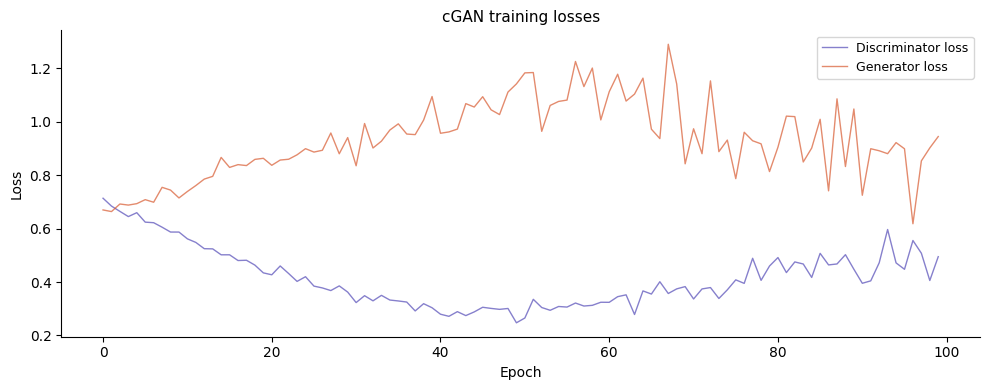

In [52]:
# ── Training loop ────────────────────────────────────────────────────────────
real_label = np.ones((BATCH_SIZE, 1), dtype='float32')
fake_label = np.zeros((BATCH_SIZE, 1), dtype='float32')

d_losses, g_losses = [], []

print(f'\nTraining cGAN for {CGAN_EPOCHS} epochs...')
for epoch in range(CGAN_EPOCHS):

    # ── Train Discriminator ──────────────────────────────────────────────────
    # Sample real batch
    idx      = np.random.randint(0, X_flat_scaled.shape[0], BATCH_SIZE)
    real_x   = X_flat_scaled[idx].astype('float32')
    real_y   = y_flat[idx].reshape(-1, 1).astype('int32')

    # Generate fake batch
    noise    = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM)).astype('float32')
    fake_y   = np.random.randint(0, N_CLASSES,
                                 (BATCH_SIZE, 1)).astype('int32')
    fake_x   = generator.predict([noise, fake_y], verbose=0)

    # Train on real then fake
    discriminator.trainable = True
    d_loss_real = discriminator.train_on_batch([real_x, real_y], real_label)
    d_loss_fake = discriminator.train_on_batch([fake_x, fake_y], fake_label)
    d_loss      = 0.5 * (d_loss_real[0] + d_loss_fake[0])

    # ── Train Generator ──────────────────────────────────────────────────────
    discriminator.trainable = False
    noise  = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM)).astype('float32')
    gen_y  = np.random.randint(0, N_CLASSES,
                               (BATCH_SIZE, 1)).astype('int32')
    g_loss = cgan.train_on_batch([noise, gen_y], real_label)

    d_losses.append(d_loss)
    g_losses.append(g_loss)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:4d}/{CGAN_EPOCHS} | '
              f'D loss: {d_loss:.4f} | G loss: {g_loss:.4f}')

print('\ncGAN training complete.')

# ── Plot GAN training losses ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(d_losses, color='#534AB7', linewidth=1,
        alpha=0.7, label='Discriminator loss')
ax.plot(g_losses, color='#D85A30', linewidth=1,
        alpha=0.7, label='Generator loss')
ax.set_title('cGAN training losses', fontsize=11)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
plt.savefig('cgan_losses.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
import numpy as np
import pandas as pd

# ── How many synthetic samples to generate ───────────────────────────────────
# Generate enough to balance Non Fatigue up to match Fatigue count
n_non_Fatigue   = (y_flat == 0).sum()
n_Fatigue  = (y_flat == 1).sum()
n_synth     = n_Fatigue - n_non_Fatigue   # fill the gap
print(f'Real   — Non Fatigue: {n_non_Fatigue}  Fatigue: {n_Fatigue}')
print(f'Generating {n_synth} synthetic Non Fatigue windows from cGAN Generator...')

# ── Generate synthetic Non Fatigue windows ───────────────────────────────────────
noise_synth  = np.random.normal(0, 1,
               (n_synth, LATENT_DIM)).astype('float32')
labels_synth = np.zeros((n_synth, 1), dtype='int32')  # class 0 = Non Fatigue

synth_scaled = generator.predict([noise_synth, labels_synth], verbose=0)

# Inverse transform back to original feature scale
synth_features = mms.inverse_transform(synth_scaled).astype('float32')
synth_labels   = np.zeros(n_synth, dtype='int32')   # binary 0 = Relaxed

print(f'Synthetic windows shape : {synth_features.shape}')

# ── Build augmented flat dataframe ───────────────────────────────────────────
real_df  = train_df[FEATURE_COLS + ['label', 'worker']].copy()
real_df['label_bin'] = (real_df['label'] > 0).astype(int)

synth_df = pd.DataFrame(synth_features, columns=FEATURE_COLS)
synth_df['label']     = 0       # original 3-class label (Relaxed)
synth_df['label_bin'] = 0       # binary label
synth_df['worker']    = -1      # synthetic worker marker

aug_df = pd.concat([real_df, synth_df], ignore_index=True)

print(f'\nAugmented flat df shape : {aug_df.shape}')
print(f'Non Fatigue : {(aug_df["label_bin"]==0).sum()}')
print(f'Fatigue: {(aug_df["label_bin"]==1).sum()}')

# ── Build sequences from augmented data ──────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler_aug = StandardScaler()
scaler_aug.fit(aug_df[FEATURE_COLS].values)

def build_sequences_aug(df, scaler, seq_len=SEQ_LEN):
    """Build sequences — handles synthetic worker=-1 separately."""
    X_seqs, y_seqs = [], []
    for worker_id, grp in df.groupby('worker'):
        grp    = grp.reset_index(drop=True)
        scaled = scaler.transform(grp[FEATURE_COLS].values)
        labels = grp['label_bin'].values
        for i in range(seq_len, len(grp)):
            X_seqs.append(scaled[i - seq_len : i])
            y_seqs.append(labels[i])
    return (np.array(X_seqs, dtype=np.float32),
            np.array(y_seqs, dtype=np.int64))

X_aug_train, y_aug_train = build_sequences_aug(aug_df, scaler_aug)

print(f'\nAugmented sequences shape : {X_aug_train.shape}')
print(f'Non Fatigue : {(y_aug_train==0).sum()}')
print(f'Fatigue: {(y_aug_train==1).sum()}')

# ── Also build val/test with same scaler ─────────────────────────────────────
X_val_aug,  y_val_aug  = build_sequences_aug(
    val_sub.assign(label_bin=(val_sub['label']>0).astype(int)),
    scaler_aug)
X_test_aug, y_test_aug = build_sequences_aug(
    test_df.assign(label_bin=(test_df['label']>0).astype(int)),
    scaler_aug)

print(f'\nVal  sequences : {X_val_aug.shape}')
print(f'Test sequences : {X_test_aug.shape}')

Real   — Non Fatigue: 1334  Fatigue: 2418
Generating 1084 synthetic Non Fatigue windows from cGAN Generator...
Synthetic windows shape : (1084, 22)

Augmented flat df shape : (4836, 25)
Non Fatigue : 2418
Fatigue: 2418

Augmented sequences shape : (4791, 5, 22)
Non Fatigue : 2373
Fatigue: 2418

Val  sequences : (474, 5, 22)
Test sequences : (806, 5, 22)


In [54]:
# Cell 38c — Train binary LSTM on cGAN-augmented data
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, f1_score

tf.random.set_seed(42)

# ── Build LSTM (same architecture as your best model) ────────────────────────
lstm_aug = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, N_FEATURES),
         return_sequences=True),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid'),
], name='LSTM_cGAN_augmented')

lstm_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall']
)

# No class_weight needed — cGAN already balanced the classes
callbacks_aug = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=0),
]

print('\nTraining LSTM on cGAN-augmented data...')
history_aug = lstm_aug.fit(
    X_aug_train, y_aug_train,
    validation_data=(X_val_aug, y_val_aug),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_aug,
    verbose=1
)


Training LSTM on cGAN-augmented data...
Epoch 1/100
75/75 [==============================] - 4s 20ms/step - loss: 0.4579 - accuracy: 0.8286 - precision: 0.8033 - recall: 0.8747 - val_loss: 0.4634 - val_accuracy: 0.8249 - val_precision: 0.8165 - val_recall: 0.9117 - lr: 0.0010
Epoch 2/100
75/75 [==============================] - 1s 10ms/step - loss: 0.2522 - accuracy: 0.9086 - precision: 0.8929 - recall: 0.9305 - val_loss: 0.3839 - val_accuracy: 0.8291 - val_precision: 0.8237 - val_recall: 0.9081 - lr: 0.0010
Epoch 3/100
75/75 [==============================] - 1s 11ms/step - loss: 0.2079 - accuracy: 0.9155 - precision: 0.8967 - recall: 0.9409 - val_loss: 0.3004 - val_accuracy: 0.8312 - val_precision: 0.8328 - val_recall: 0.8975 - lr: 0.0010
Epoch 4/100
75/75 [==============================] - 1s 11ms/step - loss: 0.1783 - accuracy: 0.9288 - precision: 0.9166 - recall: 0.9450 - val_loss: 0.3002 - val_accuracy: 0.8692 - val_precision: 0.9547 - val_recall: 0.8198 - lr: 0.0010
Epoch 5/100


=== cGAN+LSTM Evaluation ===
Accuracy  : 0.9082
Precision : 0.8992
Recall    : 0.9767
F1 Score  : 0.9363
Best Threshold : 0.000

cGAN+LSTM Classification Report:
               precision    recall  f1-score   support

 Non Fatigue       0.94      0.76      0.84       249
     Fatigue       0.90      0.98      0.94       557

    accuracy                           0.91       806
   macro avg       0.92      0.87      0.89       806
weighted avg       0.91      0.91      0.91       806


=== Summary ===
AUC Score      : 0.866
Best Threshold : 0.000
Best F1 Score  : 0.936


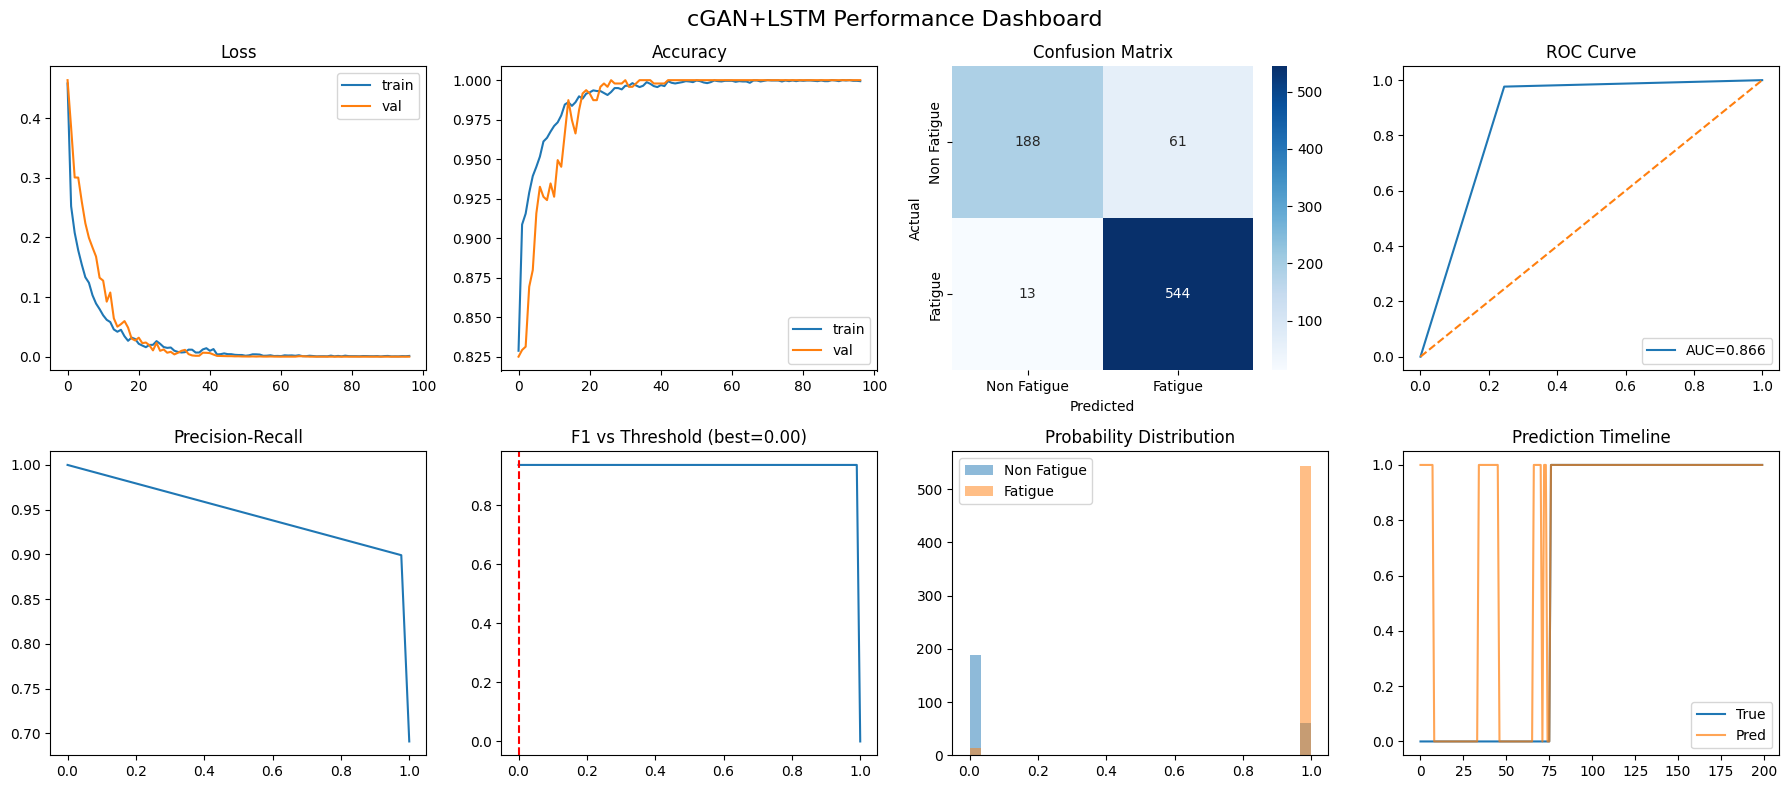

In [55]:
y_true = y_test_aug
#y_prob = lstm_aug.predict(X_seq_test).flatten()
y_pred_aug = (lstm_aug.predict(
    X_test_aug, verbose=0) > 0.5).astype(int).flatten()
# Evaluate
metrics = evaluate_dl(y_true, y_pred_aug, label="cGAN+LSTM")
model_results_append(model_results, train_metrics=None, test_metrics=metrics, model_name='cGAN+LSTM', 
                     mode='dl', history=history_aug, metrics=metrics)
plot_dashboard_dl(metrics, y_true, y_pred_aug, history_aug, title="cGAN+LSTM")


Testing: 64-32, d=0.2, lr=0.0005, batch=32, bi=False
Epoch 1/50
150/150 [==============================] - 5s 16ms/step - loss: 0.4407 - accuracy: 0.8412 - precision: 0.8454 - recall: 0.8387 - f1_score: 0.8331 - val_loss: 0.4719 - val_accuracy: 0.8376 - val_precision: 0.8121 - val_recall: 0.9470 - val_f1_score: 0.5994 - lr: 5.0000e-04
Epoch 2/50
150/150 [==============================] - 2s 11ms/step - loss: 0.2549 - accuracy: 0.9046 - precision: 0.8814 - recall: 0.9371 - f1_score: 0.9056 - val_loss: 0.3969 - val_accuracy: 0.8312 - val_precision: 0.8104 - val_recall: 0.9364 - val_f1_score: 0.5825 - lr: 5.0000e-04
Epoch 3/50
150/150 [==============================] - 2s 11ms/step - loss: 0.2143 - accuracy: 0.9115 - precision: 0.8852 - recall: 0.9475 - f1_score: 0.9142 - val_loss: 0.3214 - val_accuracy: 0.8291 - val_precision: 0.8098 - val_recall: 0.9329 - val_f1_score: 0.5775 - lr: 5.0000e-04
Epoch 4/50
150/150 [==============================] - 2s 11ms/step - loss: 0.1857 - accuracy: 

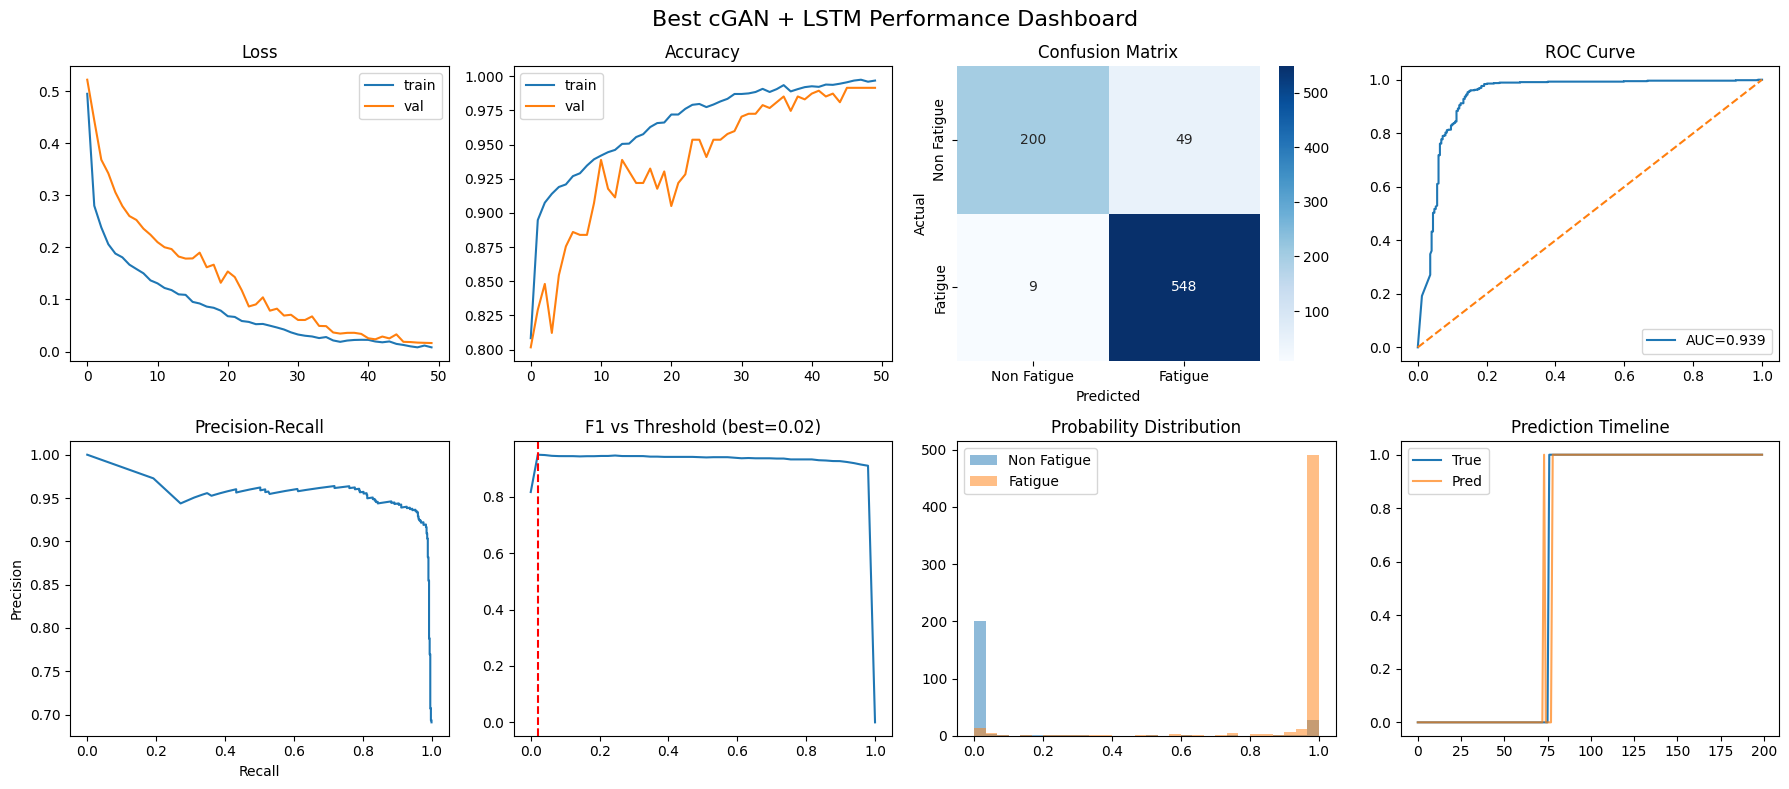

In [56]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

tf.random.set_seed(42)
np.random.seed(42)

# ── Grid ───────────────────────────────────────────────────
'''param_grid = {
    "lstm1": [64, 128],
    "lstm2": [32, 64],
    "dropout": [0.2, 0.3],
    "lr": [5e-4, 1e-3],
    "batch": [32, 64],
    "bidirectional": [False, True]
}'''

param_grid = {
    "lstm1": [64, 128],
    "lstm2": [32, 64],
    "dropout": [0.2, 0.3],
    "lr": [5e-4, 1e-3],
    "batch": [32, 64],
    "bidirectional": [False, True]
}

results = []

best_model = None
best_history = None
best_f1 = 0
best_params = None

# To Calculate F1 Score (for DL model evaluation)
def f1_score(y_true, y_pred):
    y_pred = tf.round(y_pred)
    tp = K.sum(K.cast(y_true * y_pred, 'float'))
    fp = K.sum(K.cast((1-y_true) * y_pred, 'float'))
    fn = K.sum(K.cast(y_true * (1-y_pred), 'float'))

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

# ── Grid Search ────────────────────────────────────────────
for lstm1 in param_grid["lstm1"]:
    for lstm2 in param_grid["lstm2"]:
        for dropout in param_grid["dropout"]:
            for lr in param_grid["lr"]:
                for batch in param_grid["batch"]:
                    for bi in param_grid["bidirectional"]:

                        print(f"\nTesting: {lstm1}-{lstm2}, d={dropout}, lr={lr}, batch={batch}, bi={bi}")

                        # ── Model ───────────────────────
                        model = Sequential()

                        if bi:
                            model.add(Bidirectional(
                                LSTM(lstm1, return_sequences=True),
                                input_shape=(SEQ_LEN, N_FEATURES)
                            ))
                        else:
                            model.add(LSTM(lstm1, return_sequences=True,
                                           input_shape=(SEQ_LEN, N_FEATURES)))

                        model.add(Dropout(dropout))

                        if bi:
                            model.add(Bidirectional(LSTM(lstm2)))
                        else:
                            model.add(LSTM(lstm2))

                        model.add(Dropout(dropout))

                        model.add(Dense(32, activation='relu'))
                        model.add(Dense(1, activation='sigmoid'))

                        model.compile(
                            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                            loss='binary_crossentropy',
                            metrics=['accuracy', 'Precision', 'Recall', f1_score]
                        )

                        # ── Callbacks ───────────────────
                        callbacks = [
                            EarlyStopping(monitor='val_loss', patience=5,
                                          restore_best_weights=True),
                            ReduceLROnPlateau(monitor='val_loss', patience=3)
                        ]

                        # ── Train ───────────────────────
                        history = model.fit(
                            X_aug_train, y_aug_train,
                            validation_data=(X_val_aug, y_val_aug),
                            epochs=50,
                            batch_size=batch,
                            verbose=1,
                            callbacks=callbacks
                        )

                        # ── Predictions ─────────────────
                        y_prob = model.predict(X_seq_test).flatten()

                        thresholds = np.linspace(0, 1, 50)
                        f1_scores = [f1_score(y_seq_test, (y_prob > t).astype(int)) for t in thresholds]

                        best_t = thresholds[np.argmax(f1_scores)]
                        y_pred = (y_prob > best_t).astype(int)

                        # ── Metrics ─────────────────────
                        test_f1 = f1_score(y_seq_test, y_pred)
                        test_acc = accuracy_score(y_seq_test, y_pred)
                        test_precision = precision_score(y_seq_test, y_pred)
                        test_recall = recall_score(y_seq_test, y_pred)

                        train_acc = float(history.history['accuracy'][-1])
                        val_acc = float(history.history['val_accuracy'][-1])

                        print(f" Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Test F1: {test_f1:.3f}")

                        # ── Store results ───────────────
                        results.append({
                            "lstm1": lstm1,
                            "lstm2": lstm2,
                            "dropout": dropout,
                            "lr": lr,
                            "batch": batch,
                            "bidirectional": bi,
                            "train_acc": train_acc,
                            "val_acc": val_acc,
                            "test_f1": test_f1,
                            "test_acc": test_acc
                        })

                        # ── Best model tracking ─────────
                        if test_f1 > best_f1:
                            best_f1 = test_f1
                            best_model = model
                            best_history = history
                            best_params = {
                                "lstm1": lstm1,
                                "lstm2": lstm2,
                                "dropout": dropout,
                                "lr": lr,
                                "batch": batch,
                                "bidirectional": bi
                            }

# ── Results ────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values(by="test_f1", ascending=False)

print("\nTOP CONFIGS:")
print(results_df.head(10))

print("\nBest Params:", best_params)
print("Best F1:", best_f1)

# ── Store in global model table ────────────────────────────
best_metrics = {
    "acc": test_acc,
    "precision": test_precision,
    "recall": test_recall,
    "f1": best_f1,
    "best_t": best_t,
    "best_f1": best_f1,
    "thresholds": thresholds,
    "f1_scores": f1_scores,
    "y_pred": y_pred
}

model_results_append(
    model_results,
    model_name="cGAN_LSTM",
    mode='dl',
    history=best_history,
    metrics=best_metrics
)

# ── Plot Dashboard ─────────────────────────────────────────
plot_dashboard_GS(
    best_model,
    best_history,
    X_seq_test,
    y_seq_test,
    title="Best cGAN + LSTM"
)

# Comprehensive Model Comparison & Statistical Analysis
Compare all trained models on 8 metrics: **Train & Test** × **Accuracy, Precision, Recall, F1-Score**

In [57]:
import pandas as pd

def create_beautiful_table(model_results):
    df = pd.DataFrame(model_results)

    # ── Select relevant columns ────────────────────────────────────────────
    cols = [
        "model",
        "train_acc", "val_acc", "test_acc",
        "train_f1", "val_f1", "test_f1",
        "test_precision", "test_recall",
        "test_auc"
    ]
    df = df[[c for c in cols if c in df.columns]]

    # ── Rename columns ─────────────────────────────────────────────────────
    rename_dict = {
        "model": "Model",
        "train_acc": "Train Acc",
        "val_acc": "Val Acc",
        "test_acc": "Test Acc",
        "train_f1": "Train F1",
        "val_f1": "Val F1",
        "test_f1": "Test F1",
        "test_precision": "Precision",
        "test_recall": "Recall",
        "test_auc": "AUC"
    }
    df = df.rename(columns=rename_dict)

    # ──  Convert all numeric columns safely ───────────────────────────────
    for col in df.columns:
        if col != "Model":
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # ── Round values ───────────────────────────────────────────────────────
    df = df.round(4)

    # ── Sort ───────────────────────────────────────────────────────────────
    if "Test F1" in df.columns:
        df = df.sort_values(by="Test F1", ascending=False)

    # ── Rank ───────────────────────────────────────────────────────────────
    if "Test F1" in df.columns:
        df["Rank"] = df["Test F1"].rank(ascending=False, method="min").astype("Int64")

    return df

pretty_df = create_beautiful_table(model_results)
#display(pretty_df)

# Save
SAVE_PATH = r"F:\TAN paper\results"
pretty_df.to_csv(f"{SAVE_PATH}/model_comparison.csv", index=False)

In [83]:
# Remove the 'TAN(LSTM_alone)' row from filtered_results (assuming 'LSTM' refers to the baseline LSTM model)
filtered_data = [row for row in filtered_data if row['model'] != 'LSTM']

In [85]:
import pandas as pd
import numpy as np

exclude = {'TAN_v1', 'TAN_v2', 'cGAN+LSTM', 'LSTM'}
keep_cols = [
    'model',
    'train_acc', 'train_precision', 'train_recall', 'train_f1',
    'test_acc', 'test_precision', 'test_recall', 'test_f1'
]

filtered_df = (
    pd.DataFrame(model_results)
      .loc[lambda df: ~df['model'].isin(exclude), keep_cols]
      .sort_values('test_acc', ascending=False)
      .reset_index(drop=True)
)

## Reorder columns: test metrics first, then train metrics
test_cols = ['test_acc', 'test_precision', 'test_recall', 'test_f1']
train_cols = ['train_acc', 'train_precision', 'train_recall', 'train_f1']
filtered_df = filtered_df[['model'] + test_cols + train_cols]

rename_map = {
    'LSTM_SelfAttention': 'TAN(LSTM+Self_attn)',
    'TAN_LSTM_DAN': 'TAN(LSTM+Self_attn+Gen_attn)',
    'baseline_LSTM': 'TAN(LSTM_alone)',
    'cGAN_LSTM': 'LSTM(cGAN_augmented)'
}

filtered_df['model'] = filtered_df['model'].replace(rename_map)
filtered_results = filtered_df.to_dict(orient='records')
filtered_df

,model,test_acc,test_precision,test_recall,test_f1,train_acc,train_precision,train_recall,train_f1
0,TAN(LSTM+Self_attn),0.949132,0.937288,0.992819,0.964254,0.951506,0.952925,0.976581,0.964627
1,TAN(LSTM+Self_attn+Gen_attn),0.936725,0.921667,0.992819,0.955920,0.987322,0.989274,0.991207,0.990171
2,LSTM(cGAN_augmented),0.893300,0.919786,0.926391,0.949740,0.996869,0.997515,0.996278,0.996922
3,TAN(LSTM_alone),0.885856,0.876823,0.971275,0.921635,0.984012,0.990597,0.985148,0.987530
4,Logistic Regression,0.877451,0.847793,1.000000,0.917628,0.845682,0.813288,0.987179,0.891836
5,SVM,0.859069,0.828869,1.000000,0.906428,0.926972,0.909473,0.984698,0.945592
6,Random Forest,0.835784,0.859083,0.908438,0.883071,0.916045,0.901489,0.976427,0.937463


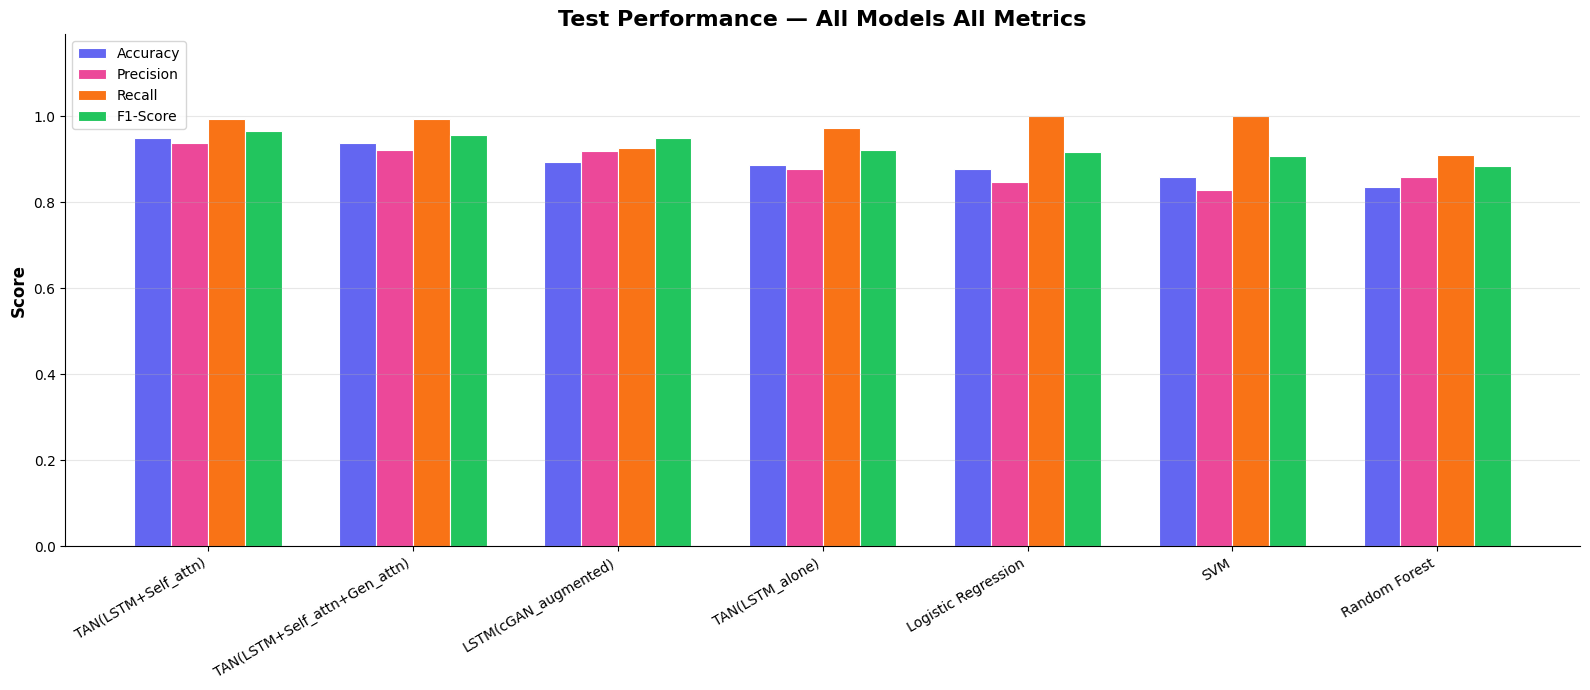

In [99]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Convert model_results to DataFrame
comparison_df = pd.DataFrame(filtered_df)

# Select relevant columns (test metrics)
test_cols = ['test_acc', 'test_precision', 'test_recall', 'test_f1']
test_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_colors = ['#6366F1', '#EC4899', '#F97316', '#22C55E']

# Get model names
models = comparison_df['model'].tolist()
n_models = len(models)

# Create the plot
fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(n_models)
width = 0.18

for i, (col, label, mc) in enumerate(zip(test_cols, test_labels, metric_colors)):
    vals = comparison_df[col].values
    bars = ax.bar(x + i * width, vals, width, color=mc, label=label,
                  edgecolor='white', linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        '''ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7,
                fontweight='bold')'''

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, 1.19)
ax.set_title('Test Performance — All Models All Metrics',
             fontsize=16, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('comparison_test_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

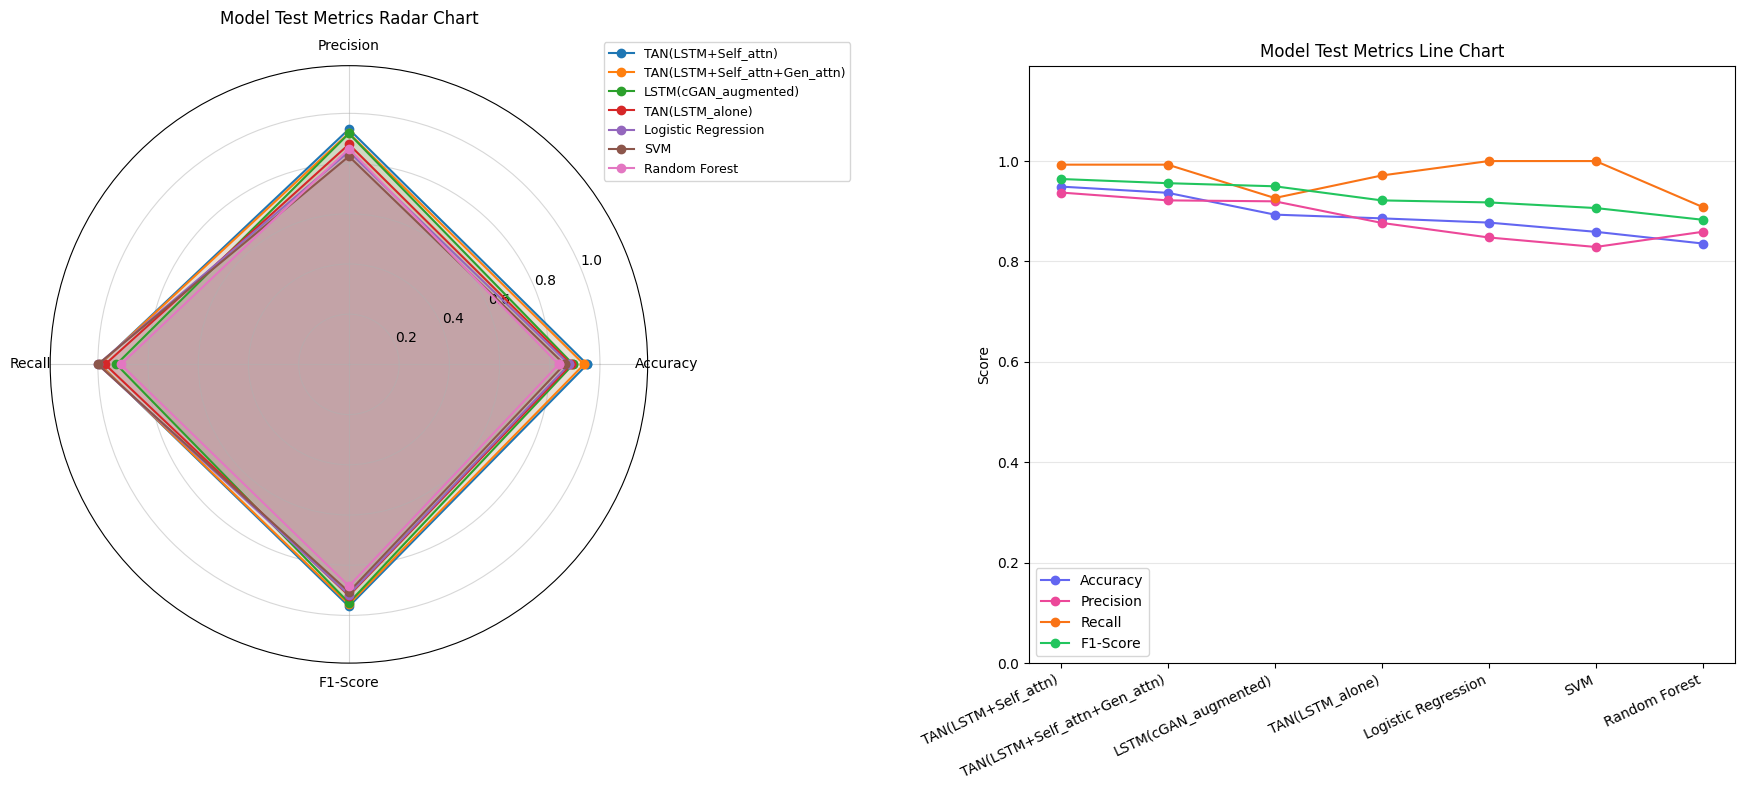

In [101]:
# Radar + line charts for filtered model comparison
metrics = ['test_acc', 'test_precision', 'test_recall', 'test_f1']
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

n_models = len(filtered_df)
models = filtered_df['model'].tolist()

# Radar chart setup
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(18, 8))

ax_radar = fig.add_subplot(1, 2, 1, polar=True)
for _, row in filtered_df.iterrows():
    values = row[metrics].values.tolist()
    values += values[:1]
    ax_radar.plot(angles, values, marker='o', linewidth=1.5, label=row['model'])
    ax_radar.fill(angles, values, alpha=0.12)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(labels)
ax_radar.set_ylim(0, 1.19)
ax_radar.set_title('Model Test Metrics Radar Chart', pad=30)
ax_radar.grid(True, alpha=0.5)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.05), fontsize=9)

# Line chart setup
ax_line = fig.add_subplot(1, 2, 2)
x = np.arange(n_models)

for metric, color, label in zip(metrics, metric_colors, labels):
    ax_line.plot(x, filtered_df[metric].values,
                 marker='o', linestyle='-', color=color,
                 label=label)

ax_line.set_xticks(x)
ax_line.set_xticklabels(models, rotation=25, ha='right')
ax_line.set_ylim(0, 1.19)
ax_line.set_title('Model Test Metrics Line Chart')
ax_line.set_ylabel('Score')
ax_line.grid(axis='y', alpha=0.3)
ax_line.legend(loc='lower left')

plt.tight_layout()
plt.show()

### SHAP and LIME Explainer

4/4 [==============================] - 0s 6ms/step


  0%|          | 0/100 [00:00<?, ?it/s]

313/313 [==============================] - 1s 3ms/step


<Figure size 640x480 with 0 Axes>

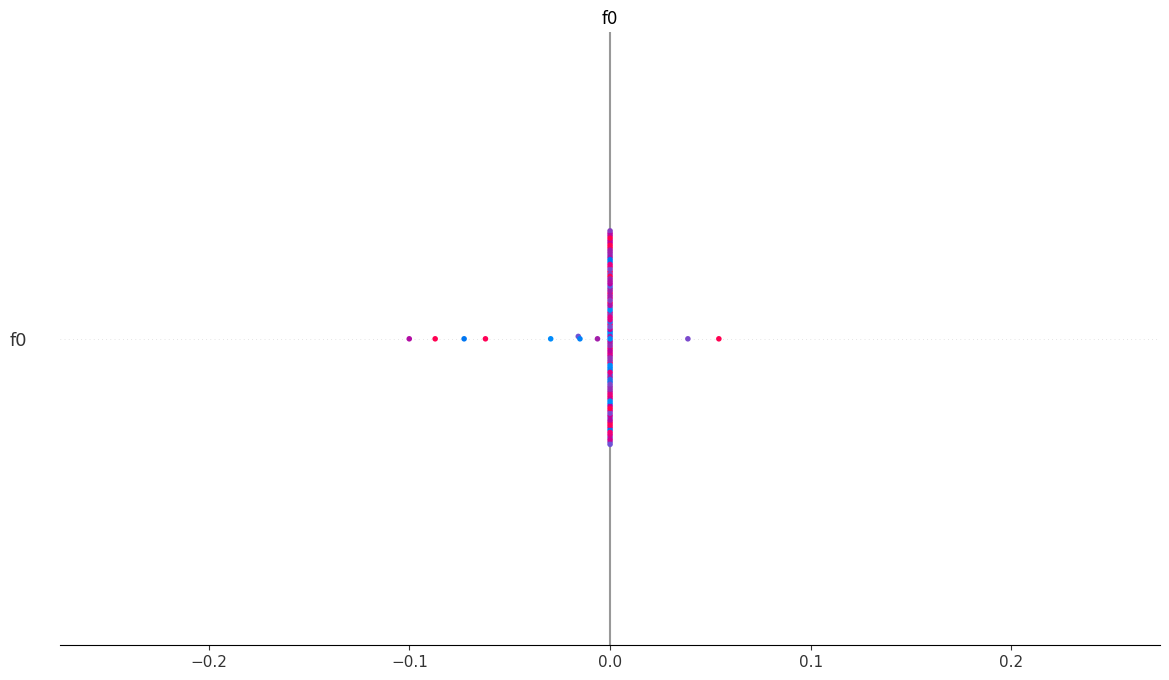

In [61]:
import shap
import numpy as np

# ── Prepare small background (important for speed)
background = X_seq_train[np.random.choice(X_seq_train.shape[0], 100, replace=False)]

# Flatten input for SHAP
def model_predict(x):
    x = x.reshape((-1, SEQ_LEN, N_FEATURES))
    return best_model.predict(x)

explainer = shap.KernelExplainer(
    model_predict,
    background.reshape((background.shape[0], -1))
)

# Sample test data
X_sample = X_seq_test[:100]
X_sample_flat = X_sample.reshape((X_sample.shape[0], -1))

# Compute SHAP values
shap_values = explainer.shap_values(X_sample_flat, nsamples=100)

# ── Plot (GLOBAL)
shap.summary_plot(
    shap_values,
    X_sample_flat,
    feature_names=[f"f{i}" for i in range(X_sample_flat.shape[1])]
)

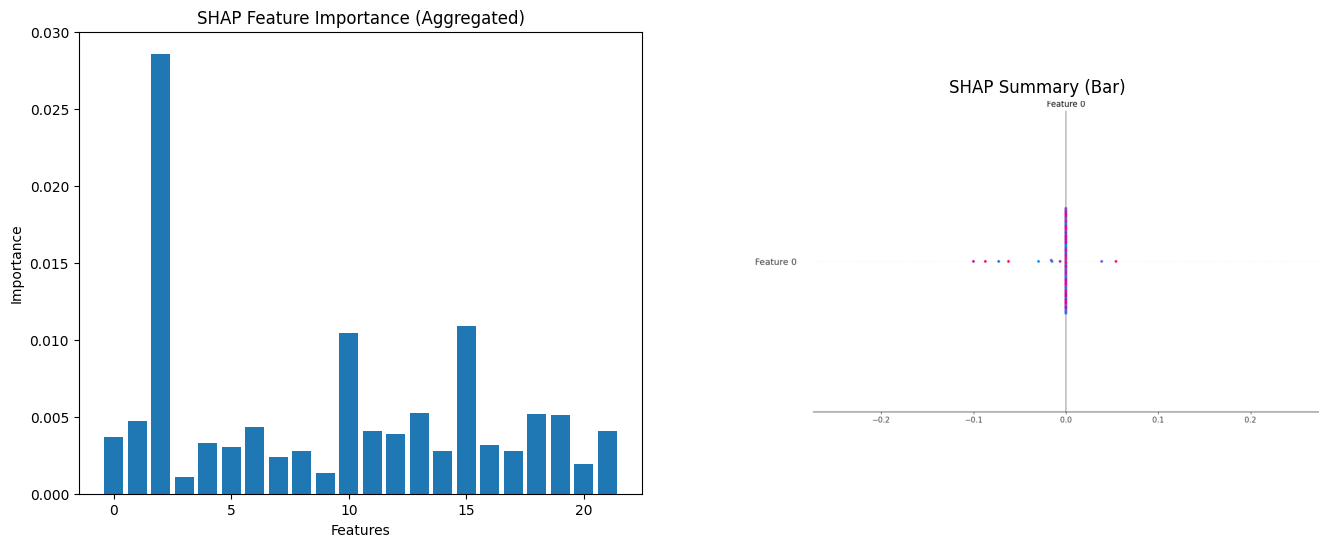

<Figure size 800x600 with 0 Axes>

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import shap

# ── Prepare SHAP aggregated importance ─────────────────────
shap_vals = np.array(shap_values)
shap_vals = shap_vals.reshape(-1, SEQ_LEN, N_FEATURES)

shap_feature_importance = np.mean(np.abs(shap_vals), axis=(0,1))

# ── Plot 1: Aggregated SHAP ────────────────────────────────
fig = plt.figure(figsize=(16, 6))

# Left plot
ax1 = fig.add_subplot(1, 2, 1)
ax1.bar(range(N_FEATURES), shap_feature_importance)
ax1.set_title("SHAP Feature Importance (Aggregated)")
ax1.set_xlabel("Features")
ax1.set_ylabel("Importance")

# ── Plot 2: SHAP Summary (separate figure rendered inline) ─
# Trick: draw SHAP plot, then copy into figure

plt.figure(figsize=(8,6))
shap.summary_plot(
    shap_values,
    X_sample_flat,
    plot_type="bar",   # safer version
    show=False
)

# Get SHAP figure
shap_fig = plt.gcf()

# Draw SHAP figure into main figure
ax2 = fig.add_subplot(1, 2, 2)

# Convert SHAP plot into image
shap_fig.canvas.draw()
img = np.frombuffer(shap_fig.canvas.tostring_rgb(), dtype='uint8')
img = img.reshape(shap_fig.canvas.get_width_height()[::-1] + (3,))

ax2.imshow(img)
ax2.axis('off')
ax2.set_title("SHAP Summary (Bar)")

plt.close(shap_fig)  # prevent duplicate display

# ── Final Layout ───────────────────────────────────────────
plt.tight_layout()
plt.show()

157/157 [==============================] - 0s 3ms/step


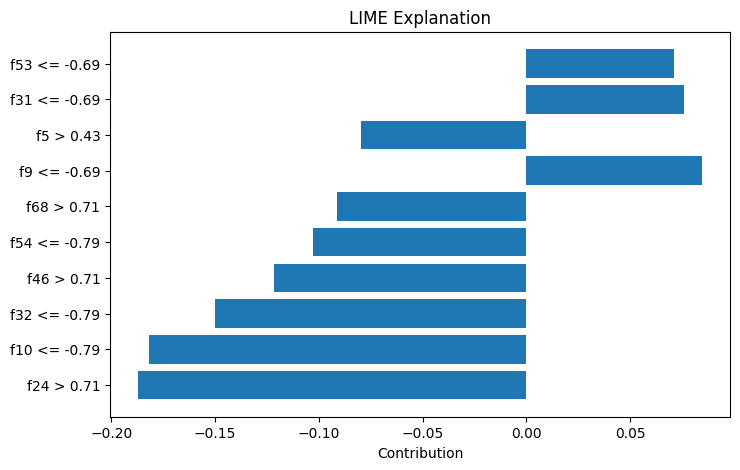

In [63]:
from lime.lime_tabular import LimeTabularExplainer

# Flatten training data
X_train_flat = X_seq_train.reshape((X_seq_train.shape[0], -1))

explainer = LimeTabularExplainer(
    X_train_flat,
    mode='classification',
    feature_names=[f"f{i}" for i in range(X_train_flat.shape[1])],
    class_names=["Non Fatigue", "Fatigue"],
    discretize_continuous=True
)

# Wrapper for model
def predict_fn(x):
    x = x.reshape((-1, SEQ_LEN, N_FEATURES))
    probs = best_model.predict(x)
    return np.hstack([1 - probs, probs])  # required format

# Explain one instance
i = 0
exp = explainer.explain_instance(
    X_seq_test.reshape((X_seq_test.shape[0], -1))[i],
    predict_fn,
    num_features=10
)

lime_weights = dict(exp.as_list())

plt.figure(figsize=(8,5))
plt.barh(list(lime_weights.keys()), list(lime_weights.values()))
plt.title("LIME Explanation")
plt.xlabel("Contribution")
plt.show()